<a href="https://colab.research.google.com/github/eles840/CFDE-Course-Module-MoTrPAC-x-Metabolomics-Workbench/blob/main/CFDE_Course_Module_MoTrPACxMetabolomics_Workbench.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integrative Metabolomics: A NIH Common Fund Data Ecosystem workflow to extract and analyze metabolomics data sets from The MoTrPAC Study and the Metabolomics Workbench

## Overview
In this notebook, you will extract and analyze metabolomics data sets from two NIH Common Fund programs as part of the **NIH Common Fund Data Ecosystem**: **MoTrPAC** and the **Metabolomics Workbench**. As an example to analyze studies from multiple sources, this workflow is designed to extract data from rat exercise training studies and to analyze overlapping metabolites in heart tissue.

### Learning Objectives
1. Leverage Metabolomics Workbench API queries to find **MoTrPAC** and **Metabolomics Workbench** studies for multi-study analysis.
2. Compare and contrast data/metadata from candidate studies
3. Analyze results to find similar/opposing metabolites from comparable studies

### Learning Assessments
Markdown questions through the notebook!

### Required Materials
This notebook is designed to run in **Google Colab**, and everything you need is provided in the notebook.

<!-- ===================================================== -->
## Data Citation (Metabolomics Workbench / NMDR)

### Projects used in this notebook

| Data source | Studies used | Project ID | Project DOI | DOI Link |
|---|---:|---|---|---|
| Metabolomics Workbench / NMDR (MoTrPAC heart studies) | 13 | **PR001020** | **10.21228/M8V97D** | https://doi.org/10.21228/M8V97D |
| Metabolomics Workbench / NMDR (Comparator study) | 1 | **PR000623** | **10.21228/M84T25** | https://doi.org/10.21228/M84T25 |

---

### How to cite NMDR data used in this notebook

**MoTrPAC heart studies (Project PR001020):**  
This data is available at the NIH Common Fund's National Metabolomics Data Repository (NMDR) website, the Metabolomics Workbench, https://www.metabolomicsworkbench.org where it has been assigned Project ID **PR001020**. The data can be accessed directly via its Project DOI: **10.21228/M8V97D** (https://doi.org/10.21228/M8V97D). This work is supported by NIH grant **U2C-DK119886**.

**Comparator study (Project PR000623):**  
This data is available at the NIH Common Fund's National Metabolomics Data Repository (NMDR) website, the Metabolomics Workbench, https://www.metabolomicsworkbench.org where it has been assigned Project ID **PR000623**. The data can be accessed directly via its Project DOI: **10.21228/M84T25** (https://doi.org/10.21228/M84T25). This work is supported by NIH grant **U2C-DK119886**.

---

### How to cite Metabolomics Workbench as a general resource
“The Metabolomics Workbench, https://www.metabolomicsworkbench.org/”

<!-- ===================================================== -->

## 1) Setup

Run the cells below to install and import required Python packages, and cofigure the global environment.

In [1]:
# Install and import python packages
!pip -q install pandas==2.2.2 numpy==2.0.2 requests==2.32.4 scipy==1.16.3 statsmodels==0.14.6 seaborn==0.13.2 matplotlib-venn==1.1.2 plotly==5.24.1
import os
import re
import json
import time
import glob
import json
import textwrap
from io import StringIO
from typing import Any, Dict, List, Optional, Tuple
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from scipy.stats import ttest_ind, hypergeom, combine_pvalues
from statsmodels.stats.multitest import multipletests
import plotly.express as px

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)

print("Ready. Python packages imported.")

Ready. Python packages imported.


In [2]:
# Configure the global environment
ALPHA = 0.05
OUTDIR = "./outputs"
DATADIR = "./data"

os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(DATADIR, exist_ok=True)

print("OUTDIR:", os.path.abspath(OUTDIR))
print("DATADIR:", os.path.abspath(DATADIR))

OUTDIR: /content/outputs
DATADIR: /content/data


## 2) Test Metabolomics Workbench API Connection

Learning objective: 1

We will use the Metabolomics Workbench REST API to retrieve metabolomics data from **MoTrPAC** and the **Metabolomics Workbench**.

First, let's test the connection.

In [3]:
# Test Metabolomics Workbench API Connection

MW_BASE = "https://www.metabolomicsworkbench.org/rest"

def mw_url(endpoint: str) -> str:
    return f"{MW_BASE}/{endpoint.lstrip('/')}"

def mw_get_json_or_text(endpoint: str, timeout: int = 60) -> Tuple[str, Any]:
    url = mw_url(endpoint)
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    try:
        return url, r.json()
    except Exception:
        return url, r.text

RETRY_VERBOSE = False

def mw_get_json_or_text_retry(endpoint: str, timeout: int = 60, retries: int = 8, backoff: float = 1.5, verbose: bool = RETRY_VERBOSE):
    last_err = None
    for attempt in range(retries):
        try:
            return mw_get_json_or_text(endpoint, timeout=timeout)
        except (
            requests.exceptions.ConnectionError,
            requests.exceptions.ReadTimeout,
            requests.exceptions.ChunkedEncodingError
        ) as e:
            last_err = e
            sleep_s = backoff * (2 ** attempt)
            if verbose:
                print(f"[retry {attempt+1}/{retries}] {endpoint} -> {e} | sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)
    raise last_err

# Connectivity check
url, obj = mw_get_json_or_text("study/study_id/ST000759/summary")
print("Test of Metabolomics Workbench API querying successful:", url, "| type:", type(obj).__name__)

Test of Metabolomics Workbench API querying successful: https://www.metabolomicsworkbench.org/rest/study/study_id/ST000759/summary | type: dict


## 3) Search Metabolomics Workbench (MW) for MoTrPAC Studies

Learning Objective: 1

MoTrPAC is a large NIH-funded clinincal trial designed to map the molecular response to exercise in humans and rats.

The Metabolomics Workbench is a NIH data repository for metabolomics data, including **MoTrPAC**.

Find MoTrPAC data via keywords (e.g., **“MoTrPAC”**, **“Molecular Transducers of Physical Activity”**).  

### Reference: MoTrPAC young adult rat endurance training study IDs (MW)
Future studies may include MoTrPAC in the study title and use MoTrPAC data. Therefore, this search query may have expanded results with non-MoTrPAC-specific data.

The following Metabolomics Workbench study IDs correspond to the original **MoTrPAC young adult rat endurance exercise training** metabolomics data sets (n = 113) provided by the MoTrPAC Consortium for public release on the Metabolomics Workbench:

ST002579, ST002580, ST002581, ST002582, ST002583, ST002588, ST002589, ST002590, ST002591, ST002592, ST002593, ST002594, ST002595, ST002596, ST002597, ST002598, ST002599, ST002600, ST002601, ST002602, ST002603, ST002604, ST002605, ST002606, ST002607, ST002608, ST002609, ST002610, ST002611, ST002612, ST002613, ST002614, ST002615, ST002616, ST002617, ST002618, ST002619, ST002620, ST002621, ST002622, ST002623, ST002624, ST002625, ST002626, ST002627, ST002628, ST002629, ST002630, ST002631, ST002632, ST002633, ST002634, ST002635, ST002636, ST002637, ST002638, ST002639, ST002640, ST002641, ST002642, ST002643, ST002644, ST002645, ST002646, ST002647, ST002648, ST002649, ST002650, ST002651, ST002652, ST002653, ST002654, ST002655, ST002656, ST002657, ST002658, ST002659, ST002660, ST002661, ST002662, ST002663, ST002664, ST002665, ST002666, ST002667, ST002668, ST002669, ST002670, ST002671, ST002672, ST002673, ST002674, ST002675, ST002676, ST002677, ST002678, ST002679, ST002680, ST002682, ST002683, ST002684, ST002685, ST002686, ST002687, ST002688, ST002689, ST002690, ST002691, ST002693, ST002694, ST002695, ST002915, ST002916

### How to use the table output
The results are displayed as a **table** in the notebook output. To explore the results interactively in Colab:
  - Click the **table/grid icon** that appears when you hover over the table output (Colab’s DataFrame viewer).
  - Use the viewer’s built-in controls to **search**, **sort**, and **scroll** through all MoTrPAC studies.

In [4]:
# Search Metabolomics Workbench for MoTrPAC studies

def mw_url(endpoint: str) -> str:
    return f"{MW_BASE}/{endpoint.lstrip('/')}"

def mw_get_json_or_text(endpoint: str, timeout: int = 60) -> Any:
    url = mw_url(endpoint)
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    try:
        return r.json()
    except Exception:
        return r.text

def try_parse_tsv(text: str) -> Optional[pd.DataFrame]:
    lines = [ln for ln in text.splitlines() if ln.strip()]
    if len(lines) < 2:
        return None
    if "\t" in lines[0] and len(lines[0].split("\t")) >= 2:
        return pd.read_csv(StringIO(text), sep="\t")
    return None

def extract_st_ids(x: Any) -> List[str]:
    return sorted(set(re.findall(r"\bST\d{6}\b", str(x))))

def extract_title_from_summary(summ: Any) -> Optional[str]:
    if isinstance(summ, dict):
        for k in ["study_title", "Study Title", "title", "Title", "study", "Study"]:
            if k in summ and summ[k]:
                return str(summ[k])
        for k in summ.keys():
            if "title" in k.lower() and summ[k]:
                return str(summ[k])
    return None

def mw_search_motrpac_studies(keywords=None, save_csv=True):
    """
    Finds candidate MoTrPAC studies by keyword search, then fetches /summary for each ST
    and displays a 2-column table: study_id + title.
    """
    if keywords is None:
        keywords = ["MoTrPAC", "Molecular Transducers of Physical Activity"]

    # 1) Keyword search -> candidate ST IDs
    st_ids = set()
    for kw in keywords:
        endpoint = f"study/study_title/{requests.utils.quote(kw)}/summary"
        obj = mw_get_json_or_text(endpoint, timeout=60)

        if isinstance(obj, str):
            df = try_parse_tsv(obj)
            st_ids |= set(extract_st_ids(df if df is not None else obj))
        else:
            st_ids |= set(extract_st_ids(obj))

    st_ids = sorted(st_ids)

    print("Keywords searched:", keywords)
    print("MoTrPAC candidate studies found:", len(st_ids))

    # 2) Search summary
    rows = []
    for st in st_ids:
        summ = mw_get_json_or_text(f"study/study_id/{st}/summary", timeout=60)
        rows.append({"study_id": st, "title": extract_title_from_summary(summ)})

    motrpac_studies_df = (
        pd.DataFrame(rows)
          .drop_duplicates("study_id")
          .sort_values("study_id")
          .reset_index(drop=True)
    )

    # Optional save
    if save_csv:
        os.makedirs("./data/mw", exist_ok=True)
        motrpac_studies_df.to_csv("./data/mw/motrpac_studies.csv", index=False)

    display(motrpac_studies_df)

    # List for downstream analysis
    motrpac_study_ids = motrpac_studies_df["study_id"].tolist()

    return motrpac_studies_df, motrpac_study_ids

motrpac_studies_df, motrpac_study_ids = mw_search_motrpac_studies()


Keywords searched: ['MoTrPAC', 'Molecular Transducers of Physical Activity']
MoTrPAC candidate studies found: 113


,study_id,title
0,ST002579,MoTrPAC: Endurance exercise training study in ...
1,ST002580,MoTrPAC: Endurance exercise training study in ...
2,ST002581,MoTrPAC: Endurance exercise training study in ...
3,ST002582,MoTrPAC: Endurance exercise training study in ...
4,ST002583,MoTrPAC: Endurance exercise training study in ...
...,...,...
108,ST002693,MoTrPAC: Endurance exercise training study in ...
109,ST002694,MoTrPAC: Endurance exercise training study in ...
110,ST002695,MoTrPAC: Endurance exercise training study in ...
111,ST002915,MoTrPAC: Endurance exercise training study in ...


## 4) Search Metabolomics Workbench for Comparable Studies to MoTrPAC

Learning Objective: 1

Find Metabolomics Workbench studies that likely contain **rat exercise training** metabolomics data for multi-study analysis with the **MoTrPAC young adult rat endurance exercise training** study data. Note: **MoTrPAC** also includes human data that will be released in the future!

Search study titles for rat exercise training keywords and synonyms.


In [5]:
# Search Metabolomics Workbench for comparable studies to MoTrPAC

def mw_url(endpoint: str) -> str:
    return f"{MW_BASE}/{endpoint.lstrip('/')}"

def mw_get_json_or_text(endpoint: str, timeout: int = 60) -> Any:
    url = mw_url(endpoint)
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    try:
        return r.json()
    except Exception:
        return r.text

def try_parse_tsv(text: str) -> Optional[pd.DataFrame]:
    lines = [ln for ln in text.splitlines() if ln.strip()]
    if len(lines) < 2:
        return None
    if "\t" in lines[0] and len(lines[0].split("\t")) >= 2:
        return pd.read_csv(StringIO(text), sep="\t")
    return None

def extract_st_ids(x: Any) -> List[str]:
    return sorted(set(re.findall(r"\bST\d{6}\b", str(x))))

def extract_title_from_summary(summ: Any) -> Optional[str]:
    if isinstance(summ, dict):
        for k in ["study_title", "Study Title", "title", "Title", "study", "Study"]:
            if k in summ and summ[k]:
                return str(summ[k])
        for k in summ.keys():
            if "title" in k.lower() and summ[k]:
                return str(summ[k])
    return None

def summary_text(summ: Any) -> str:
    return str(summ).lower()

# Inputs
EXERCISE_KEYWORDS = ["exercise", "training", "trained", "treadmill", "endurance", "running", "aerobic"]
RAT_KEYWORDS = ["rat", "rattus", "sprague", "dawley", "wistar", "long-evans", "long evans"]
EXCLUDE_KEYWORDS = ["motrpac", "molecular transducers of physical activity"]
SEARCH_TERMS = ["exercise", "training", "treadmill", "endurance"]

MOTRPAC_ST_SET = set(motrpac_studies_df["study_id"].dropna().astype(str).unique()) if "motrpac_studies_df" in globals() else set()

def search_title_terms_get_st_ids(terms: List[str]) -> List[str]:
    st = set()
    for term in terms:
        endpoint = f"study/study_title/{requests.utils.quote(term)}/summary"
        obj = mw_get_json_or_text(endpoint, timeout=60)
        if isinstance(obj, str):
            df = try_parse_tsv(obj)
            st |= set(extract_st_ids(df if df is not None else obj))
        else:
            st |= set(extract_st_ids(obj))
    return sorted(st)

candidate_sts = search_title_terms_get_st_ids(SEARCH_TERMS)
print("Initial candidate study count (pre-filter):", len(candidate_sts))

rows = []
for i, st in enumerate(candidate_sts, start=1):
    if st in MOTRPAC_ST_SET:
        continue

    try:
        summ = mw_get_json_or_text(f"study/study_id/{st}/summary", timeout=60)
        title = extract_title_from_summary(summ)
        blob = summary_text(summ)

        is_rat = any(k in blob for k in RAT_KEYWORDS) or ("rat" in (title or "").lower())
        is_ex  = any(k in blob for k in EXERCISE_KEYWORDS) or any(k in (title or "").lower() for k in EXERCISE_KEYWORDS)
        is_excluded = any(k in blob for k in EXCLUDE_KEYWORDS) or any(k in (title or "").lower() for k in EXCLUDE_KEYWORDS)

        if is_rat and is_ex and (not is_excluded):
            rows.append({"study_id": st, "title": title})

    except Exception as e:
        continue

non_motrpac_rat_ex_df = pd.DataFrame(rows).drop_duplicates("study_id").sort_values("study_id").reset_index(drop=True)

print("Candidate rat exercise-training candidate studies comparable to MoTrPAC:", non_motrpac_rat_ex_df.shape[0])
display(non_motrpac_rat_ex_df)


Initial candidate study count (pre-filter): 154
Candidate rat exercise-training candidate studies comparable to MoTrPAC: 13


,study_id,title
0,ST000759,Age and exercise effect on metabolomics in rats
1,ST000762,Plasma Nucleotide/adenosine concentrations in ...
2,ST000897,Untargeted metabolomics analysis of ischemia-r...
3,ST001068,The proteomic and metabolomic characterization...
4,ST001070,The global proteomic characterization of exerc...
5,ST001072,The in-gel proteomic characterization of exerc...
6,ST001526,Mitochondrial health is enhanced in rats with ...
7,ST001780,Comparative analysis of metabolomic profiles i...
8,ST001808,Impact of high intensity and moderate exercise...
9,ST001907,Training-induced bioenergetic improvement in h...


---

## Learning Assessments (Learning Objective 1)

**Q1. Which endpoint is being used to test that the Metabolomics Workbench API is reachable in Section 2?**  
A. `refmet/match/ST000759`      
B. `study/study_id/ST000759/analysis`  
C. `study/study_id/ST000759/summary`  
D. `study/study_title/ST000759/summary`  

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: C**

- **A (Incorrect):** `refmet/match` is for metabolite name matching, not to review a study summary. `ST000759` is also a study ID, not a refmet ID or metabolite name.  
- **B (Incorrect):** `/analysis` returns analysis metadata, but it is not the endpoint used in your connectivity test cell.  
- **C (Correct):** The notebook is testing connectivity by searching for study ID in the *summary* section.
- **D (Incorrect):** `/study_title/.../summary` searches by a *title string*, not by a study accession ID.  

</details>

**Q2. Why can the current keyword search for original MoTrPAC data produce false positives?**  
A. Study titles may mention MoTrPAC even if the data are not from the original MoTrPAC upload of metabolomics data (e.g., reuse, citation, or secondary analysis).  
B. The `/study_title/.../summary` endpoint only returns targeted metabolomics studies.  
C. The Metabolomics Workbench API automatically translates “MoTrPAC” into rat-only studies.  
D. Keyword searches never return any studies unless you provide an ST accession.  

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: A**

- **A (Correct):** Titles/metadata can reference MoTrPAC without being an original MoTrPAC dataset, so keyword hits can include non-MoTrPAC studies.  
- **B (Incorrect):** The title-search endpoint is not restricted to targeted studies.  
- **C (Incorrect):** No such automatic translation/filtering exists; your filtering logic determines what’s included.  
- **D (Incorrect):** Keyword title searches do return results without ST accessions.  

</details>

## 5) Compare and Contrast MoTrPAC and Select Comparable Studies

Learning Objective: 2

Extract metadata from all **MoTrPAC** plus one comparable study (**ST000897**) with heart metabolomics data.

- Part 1: Summary Overview: review the subjects and study groups of the metabolomics studies with heart tissue.

- Part 2: Data Types: review the data between and within study groups for accurate data extraction and analysis planning.

- Part 3: Download selected studies

- Part 4: Preview study snapshots

- Part 5: Preview data in each study

- Part 6: Diagnose data for normalization and scale

In [6]:
# Part 1: Summary Overview: Heart Metabolomics Studies

# Workflow progress checks
assert "motrpac_studies_df" in globals(), "Run the MoTrPAC MW search section first to create motrpac_studies_df."
assert "mw_get_json_or_text" in globals(), "mw_get_json_or_text() is not defined. Run the MW helper/setup section first."

# Comparator (non-MoTrPAC)
COMPARATOR_STUDY_ID = "ST000897"

def extract_an_ids(x) -> list[str]:
    return sorted(set(re.findall(r"\bAN\d{6}\b", str(x))))

def get_title_from_summary(summary: dict) -> str:
    for k in ["study_title", "Study Title", "title", "Title", "study", "Study"]:
        if isinstance(summary, dict) and summary.get(k):
            return str(summary.get(k))
    return "(title not found)"

def infer_targeted_from_title(title: str) -> str:
    t = (title or "").lower()
    if "untargeted" in t:
        return "untargeted"
    if "targeted" in t:
        return "targeted"
    return "unknown"

def infer_tissue_from_title(title: str) -> str:
    m = re.search(r"tissue\s*:\s*([^,-]+)", title, flags=re.IGNORECASE)
    if m:
        return m.group(1).strip()
    if "heart" in (title or "").lower():
        return "Heart"
    return "unknown"

def parse_class_field(s: str) -> dict:
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return {}
    out = {}
    for p in str(s).split("|"):
        p = p.strip()
        if ":" in p:
            k, v = p.split(":", 1)
            out[k.strip()] = v.strip()
    return out

def looks_like_tsv(text: str) -> bool:
    lines = [ln for ln in str(text).splitlines() if ln.strip()]
    return len(lines) >= 2 and "\t" in lines[0]

def parse_tsv(text: str) -> pd.DataFrame:
    from io import StringIO
    return pd.read_csv(StringIO(text), sep="\t")

import time
import requests

def mw_get_json_or_text_retry(endpoint: str, timeout: int = 60, retries: int = 8, backoff: float = 1.5):
    last_err = None
    for attempt in range(retries):
        try:
            return mw_get_json_or_text(endpoint, timeout=timeout)
        except (
            requests.exceptions.ConnectionError,
            requests.exceptions.ReadTimeout,
            requests.exceptions.ChunkedEncodingError
        ) as e:
            last_err = e
            sleep_s = backoff * (2 ** attempt)
            print(f"[retry {attempt+1}/{retries}] {endpoint} -> {e} | sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)
    raise last_err

def get_datatable_for_an(an_id: str, timeout: int = 180, polite_sleep: float = 0.5) -> pd.DataFrame | None:
    if polite_sleep:
        time.sleep(polite_sleep)

    txt = mw_get_json_or_text_retry(f"study/analysis_id/{an_id}/datatable", timeout=timeout)
    if not isinstance(txt, str) or not looks_like_tsv(txt):
        return None
    return parse_tsv(txt)

def get_sample_counts_and_class_keys(an_id: str, timeout: int = 180) -> dict:
    """
    Pull datatable (by AN) and extract:
      - n_samples (unique Samples if present, else row count)
      - n_male / n_female if Sex exists in parsed Class
      - class_keys_preview (comma-separated keys seen in parsed Class)
    """
    dt = get_datatable_for_an(an_id, timeout=timeout)
    if dt is None:
        return {
            "n_samples": None, "n_male": None, "n_female": None,
            "sample_count_note": "datatable not TSV / not available",
            "class_keys_preview": None
        }

    n_samples = int(dt["Samples"].astype(str).nunique()) if "Samples" in dt.columns else int(dt.shape[0])

    if "Class" not in dt.columns:
        return {
            "n_samples": n_samples, "n_male": None, "n_female": None,
            "sample_count_note": "no Class column",
            "class_keys_preview": None
        }

    meta = pd.DataFrame(dt["Class"].apply(parse_class_field).tolist())
    keys = [k for k in meta.columns if str(k).strip() != ""]
    class_keys_preview = ", ".join(sorted(keys))

    if "Sex" not in meta.columns:
        return {
            "n_samples": n_samples, "n_male": None, "n_female": None,
            "sample_count_note": "Sex not in Class",
            "class_keys_preview": class_keys_preview
        }

    sex_l = meta["Sex"].astype(str).str.strip().str.lower()
    n_male = int((sex_l == "male").sum())
    n_female = int((sex_l == "female").sum())

    return {
        "n_samples": n_samples, "n_male": n_male, "n_female": n_female,
        "sample_count_note": "from datatable Class",
        "class_keys_preview": class_keys_preview
    }

def summarize_one_study(study_id: str) -> dict:
    summ = mw_get_json_or_text(f"study/study_id/{study_id}/summary", timeout=60)
    analysis = mw_get_json_or_text(f"study/study_id/{study_id}/analysis", timeout=60)

    title = get_title_from_summary(summ if isinstance(summ, dict) else {})
    tissue = infer_tissue_from_title(title)
    metab_type = infer_targeted_from_title(title)

    an_ids = extract_an_ids(analysis) or extract_an_ids(summ)
    chosen_an = an_ids[0] if an_ids else None

    counts = {
        "n_samples": None, "n_male": None, "n_female": None,
        "sample_count_note": "no analysis_id",
        "class_keys_preview": None
    }
    if chosen_an:
        counts = get_sample_counts_and_class_keys(chosen_an)

    return {
        "study_id": study_id,
        "title": title,
        "tissue_inferred": tissue,
        "metabolomics_type_inferred": metab_type,
        "n_samples": counts["n_samples"],
        "n_male": counts["n_male"],
        "n_female": counts["n_female"],
        "sample_count_note": counts["sample_count_note"],
        "class_keys_preview": counts["class_keys_preview"],
        "analysis_ids": an_ids,
        "analysis_used_for_counts": chosen_an,
    }

motrpac_heart_ids = (
    motrpac_studies_df[motrpac_studies_df["title"].str.contains("heart", case=False, na=False)]["study_id"]
    .dropna().astype(str).unique().tolist()
)
selected_heart_study_ids = motrpac_heart_ids + ([COMPARATOR_STUDY_ID] if COMPARATOR_STUDY_ID not in motrpac_heart_ids else [])

rows = [summarize_one_study(st) for st in selected_heart_study_ids]
selected_heart_studies_df = pd.DataFrame(rows).sort_values("study_id").reset_index(drop=True)

print("Selected heart metabolomics studies (ALL MoTrPAC heart + comparator):", selected_heart_studies_df.shape[0])
display(selected_heart_studies_df[[
    "study_id","title","tissue_inferred","metabolomics_type_inferred",
    "n_samples","n_male","n_female","class_keys_preview"
]])

data_dictionary = {
    "study_id": "Metabolomics Workbench study accession (ST######).",
    "title": "Study title from Metabolomics Workbench summary.",
    "tissue_inferred": "Tissue inferred from title.",
    "metabolomics_type_inferred": "Inferred from title: targeted / untargeted / unknown.",
    "n_samples": (
        "Estimated number of samples from the MW datatable for one analysis_id (the first AN_ in /analysis). "
        "Computed as unique values in the 'Samples' column if present; otherwise counts datatable rows. "
        "NOTE: may include QC/blank/standard rows depending on the study's datatable content."
    ),
    "n_male": (
        "Estimated number of male samples parsed from 'Sex:Male' in the datatable 'Class' field (if present). "
        "If QC rows lack sex labels, n_samples may be larger than n_male+n_female."
    ),
    "n_female": (
        "Estimated number of female samples parsed from 'Sex:Female' in the datatable 'Class' field (if present). "
        "If QC rows lack sex labels, n_samples may be larger than n_male+n_female."
    ),
    "class_keys_preview": (
        "Comma-separated list of metadata keys detected in the datatable 'Class' field. "
        "This helps you see which grouping variables are available (e.g., Group, Timepoint, Sex, Tissue)."
    ),
}

print("\nData dictionary for the heart metabolomics studies table:")
for k, v in data_dictionary.items():
    print(f"- {k}: {v}")


[retry 1/8] study/analysis_id/AN004325/datatable -> ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')) | sleeping 1.5s
Selected heart metabolomics studies (ALL MoTrPAC heart + comparator): 14


,study_id,title,tissue_inferred,metabolomics_type_inferred,n_samples,n_male,n_female,class_keys_preview
0,ST000897,Untargeted metabolomics analysis of ischemia-r...,Heart,untargeted,40,NaN,NaN,Animal Group
1,ST002598,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,50,25.0,25.0,"Group, Sex, Timepoint"
2,ST002599,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,90,25.0,25.0,"Group, Sex, Timepoint"
3,ST002600,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,58,25.0,25.0,"Group, Sex, Timepoint"
4,ST002601,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,58,25.0,25.0,"Group, Sex, Timepoint"
5,ST002602,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,90,25.0,25.0,"Group, Sex, Timepoint"
6,ST002603,MoTrPAC: Endurance exercise training study in ...,Heart,targeted,50,25.0,25.0,"Group, Sex, Timepoint"
7,ST002649,MoTrPAC: Endurance exercise training study in ...,Heart,untargeted,66,25.0,25.0,"Group, Sex, Timepoint"
8,ST002650,MoTrPAC: Endurance exercise training study in ...,Heart,untargeted,90,25.0,25.0,"Group, Sex, Timepoint"
9,ST002651,MoTrPAC: Endurance exercise training study in ...,Heart,untargeted,68,25.0,25.0,"Group, Sex, Timepoint"



Data dictionary for the heart metabolomics studies table:
- study_id: Metabolomics Workbench study accession (ST######).
- title: Study title from Metabolomics Workbench summary.
- tissue_inferred: Tissue inferred from title.
- metabolomics_type_inferred: Inferred from title: targeted / untargeted / unknown.
- n_samples: Estimated number of samples from the MW datatable for one analysis_id (the first AN_ in /analysis). Computed as unique values in the 'Samples' column if present; otherwise counts datatable rows. NOTE: may include QC/blank/standard rows depending on the study's datatable content.
- n_male: Estimated number of male samples parsed from 'Sex:Male' in the datatable 'Class' field (if present). If QC rows lack sex labels, n_samples may be larger than n_male+n_female.
- n_female: Estimated number of female samples parsed from 'Sex:Female' in the datatable 'Class' field (if present). If QC rows lack sex labels, n_samples may be larger than n_male+n_female.
- class_keys_preview

In [7]:
# Part 2: Review Data Types by Study x Group: Heart Metabolomics Studies

def mw_get_json_or_text_retry(endpoint: str, timeout: int = 60, retries: int = 8, backoff: float = 1.5):
    last_err = None
    for attempt in range(retries):
        try:
            return mw_get_json_or_text(endpoint, timeout=timeout)
        except (
            requests.exceptions.ConnectionError,
            requests.exceptions.ReadTimeout,
            requests.exceptions.ChunkedEncodingError
        ) as e:
            last_err = e
            sleep_s = backoff * (2 ** attempt)
            print(f"[retry {attempt+1}/{retries}] {endpoint} -> {e} | sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)
    raise last_err

def get_datatable_for_an_retry(an_id: str, timeout: int = 180, polite_sleep: float = 0.4) -> pd.DataFrame | None:
    if polite_sleep:
        time.sleep(polite_sleep)
    txt = mw_get_json_or_text_retry(f"study/analysis_id/{an_id}/datatable", timeout=timeout)
    if not isinstance(txt, str) or not looks_like_tsv(txt):
        return None
    return parse_tsv(txt)

def uniq_levels(meta: pd.DataFrame, key: str) -> list[str]:
    if key not in meta.columns:
        return []
    vals = meta[key].dropna().astype(str).str.strip()
    vals = vals[(vals != "") & (vals != "-") & (vals.str.lower() != "nan")]
    return sorted(vals.unique().tolist())

def join_levels(levels: list[str], max_items: int = 50) -> str:
    if not levels:
        return ""
    if len(levels) > max_items:
        return ", ".join(levels[:max_items]) + ", ..."
    return ", ".join(levels)

title_map = dict(zip(selected_heart_studies_df["study_id"], selected_heart_studies_df["title"]))

rows = []
for _, r in selected_heart_studies_df.iterrows():
    st = r["study_id"]
    an = r.get("analysis_used_for_counts", None)

    out = {
        "study_id": st,
        "title": title_map.get(st, ""),
        "analysis_id": an,
        "Group_levels": "",
        "Timepoint_levels": "",
        "Sex_levels": "",
        "Tissue_levels": "",
        "note": ""
    }

    if not an:
        out["note"] = "no analysis_id"
        rows.append(out)
        continue

    dt = get_datatable_for_an_retry(an, timeout=180)
    if dt is None:
        out["note"] = "datatable not TSV / not available"
        rows.append(out)
        continue

    if "Class" not in dt.columns:
        out["note"] = "no Class column"
        rows.append(out)
        continue

    meta = pd.DataFrame(dt["Class"].apply(parse_class_field).tolist())

    group_levels = uniq_levels(meta, "Group")
    animal_group_levels = uniq_levels(meta, "Animal Group")
    merged_group_levels = sorted(set(group_levels + animal_group_levels))

    out["Group_levels"] = join_levels(merged_group_levels)
    out["Timepoint_levels"] = join_levels(uniq_levels(meta, "Timepoint"))
    out["Sex_levels"] = join_levels(uniq_levels(meta, "Sex"))
    out["Tissue_levels"] = join_levels(uniq_levels(meta, "Tissue"))

    rows.append(out)

grouping_layout_df = pd.DataFrame(rows).sort_values(["study_id"]).reset_index(drop=True)

print("Grouping layout (levels) per Study ID / Analysis ID:")
display(grouping_layout_df)

Grouping layout (levels) per Study ID / Analysis ID:


,study_id,title,analysis_id,Group_levels,Timepoint_levels,Sex_levels,Tissue_levels,note
0,ST000897,Untargeted metabolomics analysis of ischemia-r...,AN001459,"Exercise Control, Exercise Ischemia/Reperfusio...",,,,
1,ST002598,MoTrPAC: Endurance exercise training study in ...,AN004270,"Control, Training","1 week of training or control time, 2 weeks of...","Female, Male",,
2,ST002599,MoTrPAC: Endurance exercise training study in ...,AN004271,"Control, QC-Blank, QC-ExternalStandard, QC-Poo...","0 hour, 1 week of training or control time, 2 ...","Female, Male",,
3,ST002600,MoTrPAC: Endurance exercise training study in ...,AN004272,"Control, QC-ExternalStandard, Training","0 hour, 1 week of training or control time, 2 ...","Female, Male",,
4,ST002601,MoTrPAC: Endurance exercise training study in ...,AN004273,"Control, QC-ExternalStandard, Training","0 hour, 1 week of training or control time, 2 ...","Female, Male",,
5,ST002602,MoTrPAC: Endurance exercise training study in ...,AN004274,"Control, QC-Blank, QC-ExternalStandard, QC-Poo...","0 hour, 1 week of training or control time, 2 ...","Female, Male",,
6,ST002603,MoTrPAC: Endurance exercise training study in ...,AN004275,"Control, Training","1 week of training or control time, 2 weeks of...","Female, Male",,
7,ST002649,MoTrPAC: Endurance exercise training study in ...,AN004321,"Control, QC-DriftCorrection, QC-Pooled, QC-Ref...","0 hour, 1 week of training or control time, 2 ...","Female, Male",,
8,ST002650,MoTrPAC: Endurance exercise training study in ...,AN004322,"Control, QC-Blank, QC-DriftCorrection, QC-Pool...","0 hour, 1 week of training or control time, 2 ...","Female, Male",,
9,ST002651,MoTrPAC: Endurance exercise training study in ...,AN004323,"Control, QC-Blank, QC-Pooled, QC-Reference, Tr...","0 hour, 1 week of training or control time, 2 ...","Female, Male",,


In [8]:
# Part 3: Download selected studies

DATA_DIR = "./data/mw/heart_selected_all"
os.makedirs(DATA_DIR, exist_ok=True)

def looks_like_tsv(text: str) -> bool:
    lines = [ln for ln in str(text).splitlines() if ln.strip()]
    return len(lines) >= 2 and "\t" in lines[0]

def parse_tsv(text: str) -> pd.DataFrame:
    return pd.read_csv(StringIO(text), sep="\t")

def extract_an_ids(x) -> list[str]:
    return sorted(set(re.findall(r"\bAN\d{6}\b", str(x))))

RETRY_VERBOSE = False

def mw_get_json_or_text_retry(endpoint: str, timeout: int = 60, retries: int = 8, backoff: float = 1.5, verbose: bool = RETRY_VERBOSE):
    last_err = None
    for attempt in range(retries):
        try:
            return mw_get_json_or_text(endpoint, timeout=timeout)
        except (
            requests.exceptions.ConnectionError,
            requests.exceptions.ReadTimeout,
            requests.exceptions.ChunkedEncodingError
        ) as e:
            last_err = e
            sleep_s = backoff * (2 ** attempt)
            if verbose:
                print(f"[retry {attempt+1}/{retries}] {endpoint} -> {e} | sleeping {sleep_s:.1f}s")
            time.sleep(sleep_s)
    raise last_err

title_map = dict(zip(selected_heart_studies_df["study_id"].astype(str), selected_heart_studies_df["title"].astype(str)))
type_map  = dict(zip(selected_heart_studies_df["study_id"].astype(str), selected_heart_studies_df["metabolomics_type_inferred"].astype(str)))

def fetch_first_datatable_for_study(study_id: str, out_dir: str, timeout: int = 180, polite_sleep: float = 0.4):
    analysis = mw_get_json_or_text_retry(f"study/study_id/{study_id}/analysis", timeout=60)
    an_ids = extract_an_ids(analysis)
    if not an_ids:
        return None

    an_id = an_ids[0]

    if polite_sleep:
        time.sleep(polite_sleep)

    txt = mw_get_json_or_text_retry(f"study/analysis_id/{an_id}/datatable", timeout=timeout)
    if not isinstance(txt, str) or not looks_like_tsv(txt):
        return None

    dt = parse_tsv(txt)
    outpath = os.path.join(out_dir, f"{study_id}_{an_id}_datatable.tsv")
    dt.to_csv(outpath, sep="\t", index=False)

    return {
        "study_id": study_id,
        "title": title_map.get(study_id, ""),
        "metabolomics_type_inferred": type_map.get(study_id, ""),
        "analysis_id": an_id,
        "shape": f"{dt.shape[0]}x{dt.shape[1]}",
        "file": outpath,
    }

# Download selected studies (targeted + untargeted)
all_heart_ids = selected_heart_studies_df["study_id"].astype(str).tolist()
print("Downloading datatables for ALL selected heart metabolomics studies:", len(all_heart_ids))

rows = []
for st in all_heart_ids:
    rec = fetch_first_datatable_for_study(st, DATA_DIR)
    if rec is not None:
        rows.append(rec)
    else:
        rows.append({
            "study_id": st,
            "title": title_map.get(st, ""),
            "metabolomics_type_inferred": type_map.get(st, ""),
            "analysis_id": None,
            "shape": None,
            "file": None
        })

dl_all = pd.DataFrame(rows).sort_values(["study_id"]).reset_index(drop=True)
display(dl_all)

print("Files now in:", DATA_DIR)
!ls -lh ./data/mw/heart_selected_all | head -n 200

,study_id,title,metabolomics_type_inferred,analysis_id,shape,file
0,ST000897,Untargeted metabolomics analysis of ischemia-r...,untargeted,AN001459,40x77,./data/mw/heart_selected_all/ST000897_AN001459...
1,ST002598,MoTrPAC: Endurance exercise training study in ...,targeted,AN004270,50x39,./data/mw/heart_selected_all/ST002598_AN004270...
2,ST002599,MoTrPAC: Endurance exercise training study in ...,targeted,AN004271,90x7,./data/mw/heart_selected_all/ST002599_AN004271...
3,ST002600,MoTrPAC: Endurance exercise training study in ...,targeted,AN004272,58x5,./data/mw/heart_selected_all/ST002600_AN004272...
4,ST002601,MoTrPAC: Endurance exercise training study in ...,targeted,AN004273,58x37,./data/mw/heart_selected_all/ST002601_AN004273...
5,ST002602,MoTrPAC: Endurance exercise training study in ...,targeted,AN004274,90x23,./data/mw/heart_selected_all/ST002602_AN004274...
6,ST002603,MoTrPAC: Endurance exercise training study in ...,targeted,AN004275,50x13,./data/mw/heart_selected_all/ST002603_AN004275...
7,ST002649,MoTrPAC: Endurance exercise training study in ...,untargeted,AN004321,66x217,./data/mw/heart_selected_all/ST002649_AN004321...
8,ST002650,MoTrPAC: Endurance exercise training study in ...,untargeted,AN004322,90x82,./data/mw/heart_selected_all/ST002650_AN004322...
9,ST002651,MoTrPAC: Endurance exercise training study in ...,untargeted,AN004323,68x170,./data/mw/heart_selected_all/ST002651_AN004323...


Files now in: ./data/mw/heart_selected_all
total 1.1M
-rw-r--r-- 1 root root  19K Jul 29 00:14 ST000897_AN001459_datatable.tsv
-rw-r--r-- 1 root root  14K Jul 29 00:14 ST002598_AN004270_datatable.tsv
-rw-r--r-- 1 root root 8.2K Jul 29 00:14 ST002599_AN004271_datatable.tsv
-rw-r--r-- 1 root root 5.4K Jul 29 00:14 ST002600_AN004272_datatable.tsv
-rw-r--r-- 1 root root  16K Jul 29 00:14 ST002601_AN004273_datatable.tsv
-rw-r--r-- 1 root root  15K Jul 29 00:14 ST002602_AN004274_datatable.tsv
-rw-r--r-- 1 root root 6.8K Jul 29 00:14 ST002603_AN004275_datatable.tsv
-rw-r--r-- 1 root root 136K Jul 29 00:14 ST002649_AN004321_datatable.tsv
-rw-r--r-- 1 root root  80K Jul 29 00:14 ST002650_AN004322_datatable.tsv
-rw-r--r-- 1 root root 117K Jul 29 00:14 ST002651_AN004323_datatable.tsv
-rw-r--r-- 1 root root 367K Jul 29 00:14 ST002652_AN004324_datatable.tsv
-rw-r--r-- 1 root root 132K Jul 29 00:14 ST002653_AN004325_datatable.tsv
-rw-r--r-- 1 root root  24K Jul 29 00:14 ST002661_AN004333_datatable.t

In [9]:
# Part 4: Preview study snapshots

motrpac_one = (
    selected_heart_studies_df.loc[selected_heart_studies_df["study_id"].astype(str) != COMPARATOR_STUDY_ID, "study_id"]
    .astype(str)
    .iloc[0]
)
STUDIES_TO_PRINT = [COMPARATOR_STUDY_ID, motrpac_one]

def extract_study_title(summary_obj) -> str:
    if isinstance(summary_obj, dict):
        for k in ["study_title", "Study Title", "title", "Title"]:
            if summary_obj.get(k):
                return str(summary_obj.get(k))
    return "(title not found)"

def shorten_blob(x: str, width: int = 110, max_lines: int = 60) -> str:
    lines = []
    for ln in str(x).splitlines():
        ln = ln.strip()
        if not ln:
            continue
        lines.extend(textwrap.wrap(ln, width=width) or [""])
        if len(lines) >= max_lines:
            lines.append("... [truncated]")
            break
    return "\n".join(lines)

def pretty_wrap_paragraph(s: str, width: int = 110) -> str:
    s = (s or "").strip()
    s = " ".join(s.split())
    return textwrap.fill(s, width=width)

def coerce_to_pretty_text(obj) -> str:
    if isinstance(obj, dict):
        return json.dumps(obj, indent=2, ensure_ascii=False)
    return str(obj)

def get_one_datatable_path_for_study(study_id: str) -> str | None:
    rec = dl_all.loc[dl_all["study_id"].astype(str) == str(study_id)]
    if rec.empty:
        return None
    p = rec["file"].iloc[0]
    if isinstance(p, str) and p and os.path.exists(p):
        return p
    return None

def preview_study_design_from_datatable(datatable_path: str, n_class_examples: int = 12):
    dt = pd.read_csv(datatable_path, sep="\t", low_memory=False)
    out = {
        "datatable_file": datatable_path,
        "datatable_shape": dt.shape,
        "n_samples_unique": int(dt["Samples"].astype(str).nunique()) if "Samples" in dt.columns else None
    }

    if "Class" in dt.columns:
        out["class_counts_top25"] = dt["Class"].astype(str).value_counts().head(25)
        out["class_examples"] = dt["Class"].astype(str).dropna().unique().tolist()[:n_class_examples]
    else:
        out["class_counts_top25"] = None
        out["class_examples"] = None

    return out

def mw_get_text(endpoint: str, timeout: int = 60) -> str:
    url = f"{MW_BASE}/{endpoint.lstrip('/')}"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.text

def extract_json_string_value_loose(text: str, key: str) -> str | None:
    """
    Extract a JSON string value for `key` from a JSON-like document WITHOUT parsing JSON.
    """
    s = text
    m = re.search(rf'"{re.escape(key)}"\s*:\s*"', s)
    if not m:
        return None

    i = m.end()
    out = []
    esc = False
    while i < len(s):
        ch = s[i]
        if esc:
            out.append(ch)
            esc = False
        else:
            if ch == "\\":
                esc = True
            elif ch == '"':
                break
            else:
                out.append(ch)
        i += 1

    val = "".join(out).strip()
    return val if val else None

def get_study_summary(study_id: str, timeout: int = 60) -> tuple[str | None, str]:
    """
    Returns (summary_text, source_label)

    Priority:
      1) mwtab/JSON extraction of STUDY_SUMMARY
      2) mwtab/JSON extraction of PROJECT_SUMMARY (fallback)
      3) mwtab text parse: STUDY_SUMMARY
      4) mwtab text parse: PR:PROJECT_SUMMARY (fallback)
    """
    try:
        mwtab_json_like = mw_get_text(f"study/study_id/{study_id}/mwtab/JSON", timeout=timeout)
        ssum = extract_json_string_value_loose(mwtab_json_like, "STUDY_SUMMARY")
        if ssum:
            return ssum, "mwtab/JSON loose: STUDY_SUMMARY"

        psum = extract_json_string_value_loose(mwtab_json_like, "PROJECT_SUMMARY")
        if psum:
            return psum, "mwtab/JSON loose: PROJECT_SUMMARY (fallback)"
    except Exception:
        pass

    try:
        mwtab_text = mw_get_text(f"study/study_id/{study_id}/mwtab", timeout=timeout)
        rows = []
        for ln in mwtab_text.replace("\r\n", "\n").splitlines():
            if not ln or ln.startswith("#") or "\t" not in ln:
                continue
            k, v = ln.split("\t", 1)
            rows.append((k.strip(), v.strip()))

        ss_lines = [v for k, v in rows if k == "STUDY_SUMMARY" and v]
        if ss_lines:
            return " ".join(ss_lines).strip(), "mwtab text: STUDY_SUMMARY"

        pr_lines = [v for k, v in rows if k == "PR:PROJECT_SUMMARY" and v]
        if pr_lines:
            return " ".join(pr_lines).strip(), "mwtab text: PR:PROJECT_SUMMARY (fallback)"
    except Exception:
        pass

    return None, "not_found"

for st in STUDIES_TO_PRINT:
    summary = mw_get_json_or_text(f"study/study_id/{st}/summary", timeout=60)
    analysis = mw_get_json_or_text(f"study/study_id/{st}/analysis", timeout=60)
    title = extract_study_title(summary)

    print("\n" + "=" * 110)
    print(f"STUDY: {st}")
    print(f"TITLE: {title}")
    print("=" * 110)

    ss, ss_src = get_study_summary(st, timeout=60)
    print("\nSTUDY SUMMARY:")
    if ss:
        print(f"[source: {ss_src}]")
        print(pretty_wrap_paragraph(ss, width=110))
    else:
        print("No Study Summary (or Project Summary fallback) found via mwTab endpoints for this study.")

    print("\nANALYSIS METADATA (/analysis):")
    print(shorten_blob(coerce_to_pretty_text(analysis), width=110, max_lines=45))

    dt_path = get_one_datatable_path_for_study(st)
    print("\nSTUDY DESIGN SNAPSHOT (from downloaded datatable):")
    if dt_path is None:
        print("No local datatable file found for this study in dl_all.")
        continue

    design = preview_study_design_from_datatable(dt_path)
    print(f"Datatable: {design['datatable_file']}")
    print(f"Shape: {design['datatable_shape'][0]} rows x {design['datatable_shape'][1]} columns")
    if design["n_samples_unique"] is not None:
        print(f"Unique Samples: {design['n_samples_unique']}")

    if design["class_counts_top25"] is not None:
        print("\nTop Class groups (count of rows):")
        display(design["class_counts_top25"].to_frame("n_rows"))
        print("\nExample Class labels:")
        for x in (design["class_examples"] or []):
            print(" -", x)
    else:
        print("No 'Class' column found in this datatable (cannot summarize study groups).")


STUDY: ST000897
TITLE: Untargeted metabolomics analysis of ischemia-reperfusion injured hearts ex vivo from sedentary and exercise trained rats.

STUDY SUMMARY:
[source: mwtab/JSON loose: STUDY_SUMMARY]
The effects of exercise on the heart and its resistance to disease are well-documented. Recent studies have
identified exercise-induced resistance to arrhythmia is due to the preservation of mitochondrial membrane
potential. To identify novel metabolic changes that occurred parallel to these mitochondrial alterations, we
performed non-targeted metabolomics analysis on hearts from sedentary (Sed) and exercise- trained (Ex) rats
challenged with isolated heart ischemia-reperfusion injury (I/R). Eight weeks old Sprague- Dawley rats were
treadmill trained five days/week for six weeks (exercise duration and intensity progressively increased to 1
hour at 30 m/min up to 10.5% incline, 75-80% VO2mx). The recovery of pre-ischemic function for sedentary rat
hearts was 28.8+/-5.4% (N=12) compared 

,n_rows
Class,
Animal Group:Exercise Control,10
Animal Group:Exercise Ischemia/Reperfusion Injury,10
Animal Group:Sedentary Control,10
Animal Group:Sedentary Ischemia/Reperfusion Injury,10



Example Class labels:
 - Animal Group:Exercise Control
 - Animal Group:Exercise Ischemia/Reperfusion Injury
 - Animal Group:Sedentary Control
 - Animal Group:Sedentary Ischemia/Reperfusion Injury

STUDY: ST002598
TITLE: MoTrPAC: Endurance exercise training study in young adult rats, Tissue:Heart - Targeted Amines

STUDY SUMMARY:
[source: mwtab/JSON loose: STUDY_SUMMARY]
The goal of the endurance exercise training study in young adult rats (internal code: PASS1B-06) was to
perform exercise training studies in adult (6 month) F344 rats, and from these rats collect as many tissues as
feasible in order to provide high quality samples for detailed analysis by chemical analysis sites. Tissues
were collected from 10-12 rats sedentary control rats concurrent with the collection of the 8-week training
groups. The 8-week training group and controls were from the same cohort and same age at euthanasia (either
8). For the older age group, an additional set of controls (n=5-6) were collected with 

,n_rows
Class,
Group:Control | Timepoint:8 weeks of training or control time | Sex:Female,5
Group:Control | Timepoint:8 weeks of training or control time | Sex:Male,5
Group:Training | Timepoint:1 week of training or control time | Sex:Female,5
Group:Training | Timepoint:1 week of training or control time | Sex:Male,5
Group:Training | Timepoint:2 weeks of training | Sex:Female,5
Group:Training | Timepoint:2 weeks of training | Sex:Male,5
Group:Training | Timepoint:4 weeks of training | Sex:Female,5
Group:Training | Timepoint:4 weeks of training | Sex:Male,5
Group:Training | Timepoint:8 weeks of training or control time | Sex:Female,5



Example Class labels:
 - Group:Control | Timepoint:8 weeks of training or control time | Sex:Female
 - Group:Control | Timepoint:8 weeks of training or control time | Sex:Male
 - Group:Training | Timepoint:1 week of training or control time | Sex:Female
 - Group:Training | Timepoint:1 week of training or control time | Sex:Male
 - Group:Training | Timepoint:2 weeks of training | Sex:Female
 - Group:Training | Timepoint:2 weeks of training | Sex:Male
 - Group:Training | Timepoint:4 weeks of training | Sex:Female
 - Group:Training | Timepoint:4 weeks of training | Sex:Male
 - Group:Training | Timepoint:8 weeks of training or control time | Sex:Female
 - Group:Training | Timepoint:8 weeks of training or control time | Sex:Male


In [10]:
# Part 5: Preview the data in each study

dt_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*_datatable.tsv")))

def parse_st_an(fname: str):
    m = re.match(r"(ST\d{6})_(AN\d{6})_datatable\.tsv$", fname)
    return (m.group(1), m.group(2)) if m else (None, None)

N_SAMPLES = 5
N_METS = 5

def value_preview(series: pd.Series, n: int = 5) -> str:
    vals = series.head(n).tolist()
    out = []
    for v in vals:
        if pd.isna(v):
            out.append("NA")
        else:
            s = str(v)
            out.append(s if len(s) <= 40 else s[:37] + "...")
    return ", ".join(out)

blocks = []
for p in dt_paths:
    fname = os.path.basename(p)
    st, an = parse_st_an(fname)

    dt = pd.read_csv(p, sep="\t", low_memory=False)

    meta_cols = [c for c in ["Samples", "Class"] if c in dt.columns]
    met_cols = [c for c in dt.columns if c not in meta_cols]
    met_cols_show = met_cols[:N_METS]

    prev = dt[meta_cols + met_cols_show].head(N_SAMPLES).copy()

    rows = []
    for col in prev.columns:
        s = prev[col]
        rows.append({
            "study_id": st,
            "analysis_id": an,
            "title": title_map.get(st, ""),
            "variable": col,
            "dtype": str(s.dtype),
            "value_preview": value_preview(s, n=N_SAMPLES),
        })

    blocks.append(pd.DataFrame(rows))

glimpse_like_df = pd.concat(blocks, ignore_index=True)

print(f"Preview data from selected studies")
display(glimpse_like_df)

Preview data from selected studies


,study_id,analysis_id,title,variable,dtype,value_preview
0,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,Samples,object,"H13, H14, H18, H2, H23"
1,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,Class,object,"Animal Group:Exercise Control, Animal Group:Ex..."
2,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,"1,2-Propanediol",float64,"14.45, 13.66, 13.81, 11.61, 13.47"
3,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,2-Aminoadipic acid,float64,"19.23, 19.42, 19.67, 19.5, 19.62"
4,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,2-Hydroxypyridine,float64,"14.52, 14.68, 14.47, 14.62, 14.9"
...,...,...,...,...,...,...
91,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,2-hydroxy-3-methylbutyrate,float64,"396751.0, 385694.0, 402195.0, 380606.0, 402047.0"
92,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,2-hydroxybutyrate,float64,"107840.0, 67537.0, 185470.0, 63439.0, 76690.0"
93,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,3-hydroxybutyrate,float64,"401142.0, 327147.0, 450136.0, 154186.0, 385140.0"
94,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,3-methyl-2-oxovalerate,float64,"16483.0, 24059.0, 12675.0, 6788.0, 23475.0"


In [11]:
# Part 6: Diagnose data for normalization and scale

title_map = dict(zip(selected_heart_studies_df["study_id"].astype(str), selected_heart_studies_df["title"].astype(str)))

KEYWORDS = [
    "normaliz", "normalized", "log", "log2", "log10",
    "scale", "scaled", "autoscale", "pareto", "z-score", "zscore",
    "tic", "total ion", "internal standard", "istd",
    "batch correction", "drift", "blank", "qc", "pooled"
]

def parse_st_an(fname: str):
    m = re.match(r"(ST\d{6})_(AN\d{6})_datatable\.tsv$", fname)
    return (m.group(1), m.group(2)) if m else (None, None)

def keyword_hits(text: str, keywords=KEYWORDS):
    t = (text or "").lower()
    hits = [k for k in keywords if k in t]
    return hits

def datatable_stats(path: str):
    dt = pd.read_csv(path, sep="\t", low_memory=False)

    meta_cols = [c for c in ["Samples", "Class"] if c in dt.columns]
    met_cols = [c for c in dt.columns if c not in meta_cols]
    if not met_cols:
        return {}

    X = dt[met_cols].apply(pd.to_numeric, errors="coerce")

    x = X.to_numpy().ravel()
    x = x[np.isfinite(x)]

    if x.size == 0:
        return {"n_metabolite_cols": len(met_cols), "n_values": 0}

    q = np.quantile(x, [0.0, 0.25, 0.5, 0.75, 1.0])
    frac_zero = float((x == 0).mean())

    return {
        "n_metabolite_cols": len(met_cols),
        "n_values": int(x.size),
        "min": float(q[0]),
        "q25": float(q[1]),
        "median": float(q[2]),
        "q75": float(q[3]),
        "max": float(q[4]),
        "pct_zero": 100.0 * frac_zero,
    }

rows = []
for p in dt_paths:
    st, an = parse_st_an(os.path.basename(p))
    if st is None:
        continue

    summ = mw_get_json_or_text(f"study/study_id/{st}/summary", timeout=60)
    anal = mw_get_json_or_text(f"study/study_id/{st}/analysis", timeout=60)

    blob = (str(summ) + "\n" + str(anal))
    hits = keyword_hits(blob)

    stats = datatable_stats(p)

    rows.append({
        "study_id": st,
        "analysis_id": an,
        "title": title_map.get(st, ""),
        "keyword_hits": ", ".join(hits[:30]) + (", ..." if len(hits) > 30 else ""),
        **stats
    })

norm_check_df = pd.DataFrame(rows).sort_values(["study_id", "analysis_id"]).reset_index(drop=True)

assert "norm_check_df" in globals(), "norm_check_df not found. Run the normalization/diagnostics block first."

def scale_heuristic(row):
    med = row.get("median", np.nan)
    mx  = row.get("max", np.nan)

    if not np.isfinite(med) or not np.isfinite(mx):
        return "unknown"

    # Heuristics (intentionally simple; not a claim about true normalization)
    if (0 < med <= 30) and (mx <= 200):
        return "log_like_(~0-30)"
    if (med > 1_000) or (mx > 1_000_000):
        return "large_intensity/area_like"
    if (med <= 5) and (mx <= 1_000):
        return "small_decimal_like"
    return "mixed/other"

norm_check_df = norm_check_df.copy()
norm_check_df["value_scale_heuristic"] = norm_check_df.apply(scale_heuristic, axis=1)

# Add a "recommended_transform" column based on the value_scale_heuristic
def recommend_transform(row):
    label = row.get("value_scale_heuristic", "unknown")
    pct_zero = row.get("pct_zero", np.nan)

    if label == "large_intensity/area_like":
        # common for peak areas/intensities
        return "log2(x + 1)"
    if label == "log_like_(~0-30)":
        # if the scale appears log-like, recommend to not transform
        return "none (already log-like)"
    if label == "small_decimal_like":
        # often concentrations/ratios, log may be optional and depends on goal
        return "none (small-scale; consider log2(x + eps) if needed)"
    if label == "mixed/other":
        # could be mixed units or wide range
        return "inspect (possible log2(x + 1) if intensity-like; otherwise none)"
    return "inspect"

norm_check_df = norm_check_df.copy()
norm_check_df["recommended_transform"] = norm_check_df.apply(recommend_transform, axis=1)

display(
    norm_check_df[[
        "study_id","analysis_id","title",
        "median","max","pct_zero",
        "value_scale_heuristic","recommended_transform"
    ]].sort_values(["value_scale_heuristic","study_id","analysis_id"])
)

,study_id,analysis_id,title,median,max,pct_zero,value_scale_heuristic,recommended_transform
7,ST002649,AN004321,MoTrPAC: Endurance exercise training study in ...,532193.000,1.237574e+09,0.782241,large_intensity/area_like,log2(x + 1)
8,ST002650,AN004322,MoTrPAC: Endurance exercise training study in ...,2610251.490,4.326272e+08,6.097222,large_intensity/area_like,log2(x + 1)
9,ST002651,AN004323,MoTrPAC: Endurance exercise training study in ...,113504.455,1.459498e+07,0.000000,large_intensity/area_like,log2(x + 1)
10,ST002652,AN004324,MoTrPAC: Endurance exercise training study in ...,260792.470,4.955780e+08,0.000000,large_intensity/area_like,log2(x + 1)
11,ST002653,AN004325,MoTrPAC: Endurance exercise training study in ...,783168.620,2.895774e+10,5.892520,large_intensity/area_like,log2(x + 1)
13,ST002916,AN004786,MoTrPAC: Endurance exercise training study in ...,72319.000,5.391144e+07,6.770026,large_intensity/area_like,log2(x + 1)
0,ST000897,AN001459,Untargeted metabolomics analysis of ischemia-r...,15.155,2.382000e+01,26.733333,log_like_(~0-30),none (already log-like)
1,ST002598,AN004270,MoTrPAC: Endurance exercise training study in ...,0.440,8.738000e+01,8.594595,log_like_(~0-30),none (already log-like)
3,ST002600,AN004272,MoTrPAC: Endurance exercise training study in ...,0.510,3.500000e+00,0.000000,log_like_(~0-30),none (already log-like)
5,ST002602,AN004274,MoTrPAC: Endurance exercise training study in ...,0.040,2.000000e+02,34.391534,log_like_(~0-30),none (already log-like)


---

## Learning Assessments (Learning Objective 2)

**Q1. Which field in the heart-study summary table best helps you determine what grouping variables are available for downstream comparisons?**  
A. `title`  
B. `tissue_inferred`  
C. `metabolomics_type_inferred`  
D. `class_keys_preview`  

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: D**

- **A (Incorrect):** Titles can hint at design, but they don’t reliably enumerate available `Class` keys.
- **B (Incorrect):** Tissue helps determine biological comparability, but not what group variables exist in the datatable.  
- **C (Incorrect):** Targeted/untargeted affects feature overlap and scaling, but not which grouping variables appear in `Class`.
- **D (Correct):** `class_keys_preview` is derived from parsing the datatable `Class` field and lists available metadata keys (e.g., Group, Timepoint, Sex).     

</details>

**Q2. What is the most likely explanation that `n_samples` is larger than `n_male + n_female` for some studies?**  
A. Some rows are QC/blank/standard samples and lack a `Sex` label.  
B. The code double-counts every male sample.  
C. The Metabolomics Workbench API returns random sample counts unless you use `/factors`.  
D. The datatable always omits female samples.  

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: A**

- **A (Correct):** Your code counts *all* samples but only counts males/females when `Sex` is present; QC rows often don’t include `Sex`.  
- **B (Incorrect):** There’s no logic that duplicates male samples.  
- **C (Incorrect):** Sample counts come directly from the datatable; the API isn’t random.  
- **D (Incorrect):** There is no rule that systematically omits female samples.  

</details>

## Analyze Results to Find Similar/Opposing Metabolites from Comparable Studies

Learning Objective: 3

Let's analyze the data to see how the selected studies compare!

We will analyze data by comparing:

- Part 1: Metabolites found across studies

- Part 2: Class distribution of shared metabolites

- Part 3: Data transformation and statistics of shared metabolites: normalization, significance, effect size, and fold change

- Part 4: Directional concordance of shared metabolites

- Part 5: Compare data interactively!


Comparator metabolites: 75
MoTrPAC targeted metabolites (union): 179
Overlap vs targeted (shared names): 12
Shared metabolite names (targeted): ['Alanine', 'Asparagine', 'Ethanolamine', 'Glutamine', 'Glycine', 'Histidine', 'Lysine', 'Proline', 'Serine', 'Taurine', 'Threonine', 'Tyrosine']

MoTrPAC untargeted metabolites (union): 1166
Overlap vs untargeted (shared names): 0
Shared metabolite names (untargeted): NONE (0 overlaps)


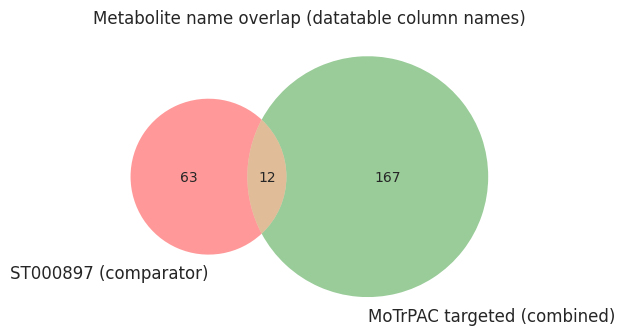

In [12]:
# Part 1: Metabolites found across studies

def refmet_match(name: str, timeout: int = 30):
    url = f"{MW_BASE}/refmet/match/{requests.utils.quote(str(name))}"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    return r.json()

_refmet_cache = {}

def refmet_match_cached(name: str, sleep_s: float = 0.0):
    if name in _refmet_cache:
        return _refmet_cache[name]
    try:
        res = refmet_match(name)
    except Exception as e:
        res = {"input_name": name, "error": str(e)}
    _refmet_cache[name] = res
    if sleep_s:
        time.sleep(sleep_s)
    return res

def annotate_datatable_metabolites_with_refmet(datatable_path: str, n_max: int | None = None, sleep_s: float = 0.0):
    dt = pd.read_csv(datatable_path, sep="\t", low_memory=False)
    met_cols = [c for c in dt.columns if c not in ["Samples", "Class"]]

    if n_max is not None:
        met_cols = met_cols[:n_max]

    rows = []
    for m in met_cols:
        resp = refmet_match_cached(m, sleep_s=sleep_s)
        rows.append({
            "input_name": m,
            "refmet_name": resp.get("refmet_name"),
            "refmet_id": resp.get("refmet_id"),
            "formula": resp.get("formula"),
            "exactmass": resp.get("exactmass"),
            "super_class": resp.get("super_class"),
            "main_class": resp.get("main_class"),
            "sub_class": resp.get("sub_class"),
            "error": resp.get("error"),
        })

    return pd.DataFrame(rows)

datatable_path = "./data/mw/heart_selected_all/ST000897_AN001459_datatable.tsv"
refmet_annot_df = annotate_datatable_metabolites_with_refmet(datatable_path, n_max=50, sleep_s=0.0)

DATA_DIR = "./data/mw/heart_selected_all"
COMPARATOR_STUDY_ID = "ST000897"

assert "selected_heart_studies_df" in globals(), "selected_heart_studies_df not found."

def parse_st(fname):
    m = re.match(r"(ST\d{6})_(AN\d{6})_datatable\.tsv$", fname)
    return m.group(1) if m else None

type_map = dict(zip(
    selected_heart_studies_df["study_id"].astype(str),
    selected_heart_studies_df["metabolomics_type_inferred"].astype(str).str.lower()
))

comp_mets = set()
targ_mets = set()
untarg_mets = set()

for p in glob.glob(os.path.join(DATA_DIR, "*_datatable.tsv")):
    st = parse_st(os.path.basename(p))
    if st is None:
        continue

    hdr = pd.read_csv(p, sep="\t", nrows=0)
    met_cols = [c for c in hdr.columns if c not in ["Samples", "Class"]]

    if st == COMPARATOR_STUDY_ID:
        comp_mets |= set(met_cols)
    else:
        t = type_map.get(st)
        if t == "targeted":
            targ_mets |= set(met_cols)
        elif t == "untargeted":
            untarg_mets |= set(met_cols)

shared_targeted = comp_mets.intersection(targ_mets)
shared_untargeted = comp_mets.intersection(untarg_mets)

print("Comparator metabolites:", len(comp_mets))
print("MoTrPAC targeted metabolites (union):", len(targ_mets))
print("Overlap vs targeted (shared names):", len(shared_targeted))
print("Shared metabolite names (targeted):", sorted(shared_targeted))
print("\nMoTrPAC untargeted metabolites (union):", len(untarg_mets))
print("Overlap vs untargeted (shared names):", len(shared_untargeted))
if len(shared_untargeted) == 0:
    print("Shared metabolite names (untargeted): NONE (0 overlaps)")
else:
    print("Shared metabolite names (untargeted):", sorted(shared_untargeted))

plt.figure(figsize=(6, 6))
venn2(
    subsets=(len(comp_mets - targ_mets), len(targ_mets - comp_mets), len(shared_targeted)),
    set_labels=(f"{COMPARATOR_STUDY_ID} (comparator)", "MoTrPAC targeted (combined)")
)
plt.title("Metabolite name overlap (datatable column names)")

plt.tight_layout()
plt.show()

Comparator metabolites: 75
MoTrPAC targeted metabolites (union): 179
Shared comparator vs MoTrPAC targeted: 12
Shared names: ['Alanine', 'Asparagine', 'Ethanolamine', 'Glutamine', 'Glycine', 'Histidine', 'Lysine', 'Proline', 'Serine', 'Taurine', 'Threonine', 'Tyrosine']
Loaded cache: 12 entries


,input_name,refmet_name,refmet_id,formula,exactmass,super_class,main_class,sub_class,error
0,Alanine,Alanine,RM0135898,C3H7NO2,89.0477,Organic acids,Amino acids and peptides,Amino acids,NaN
1,Asparagine,Asparagine,RM0135724,C4H8N2O3,132.0535,Organic acids,Amino acids and peptides,Amino acids,NaN
2,Ethanolamine,Ethanolamine,RM0040238,C2H7NO,61.0528,Organic nitrogen compounds,Amines,"1,2-aminoalcohols",NaN
3,Glutamine,Glutamine,RM0012560,C5H10N2O3,146.0691,Organic acids,Amino acids and peptides,Amino acids,NaN
4,Glycine,Glycine,RM0135888,C2H5NO2,75.0320,Organic acids,Amino acids and peptides,Amino acids,NaN
5,Histidine,Histidine,RM0129894,C6H9N3O2,155.0695,Organic acids,Amino acids and peptides,Amino acids,NaN
6,Lysine,Lysine,RM0135903,C6H14N2O2,146.1055,Organic acids,Amino acids and peptides,Amino acids,NaN
7,Proline,Proline,RM0135899,C5H9NO2,115.0633,Organic acids,Amino acids and peptides,Amino acids,NaN
8,Serine,Serine,RM0032433,C3H7NO3,105.0426,Organic acids,Amino acids and peptides,Amino acids,NaN
9,Taurine,Taurine,RM0118223,C2H7NO3S,125.0147,Organic acids,Sulfonic acids,Sulfonic acids,NaN


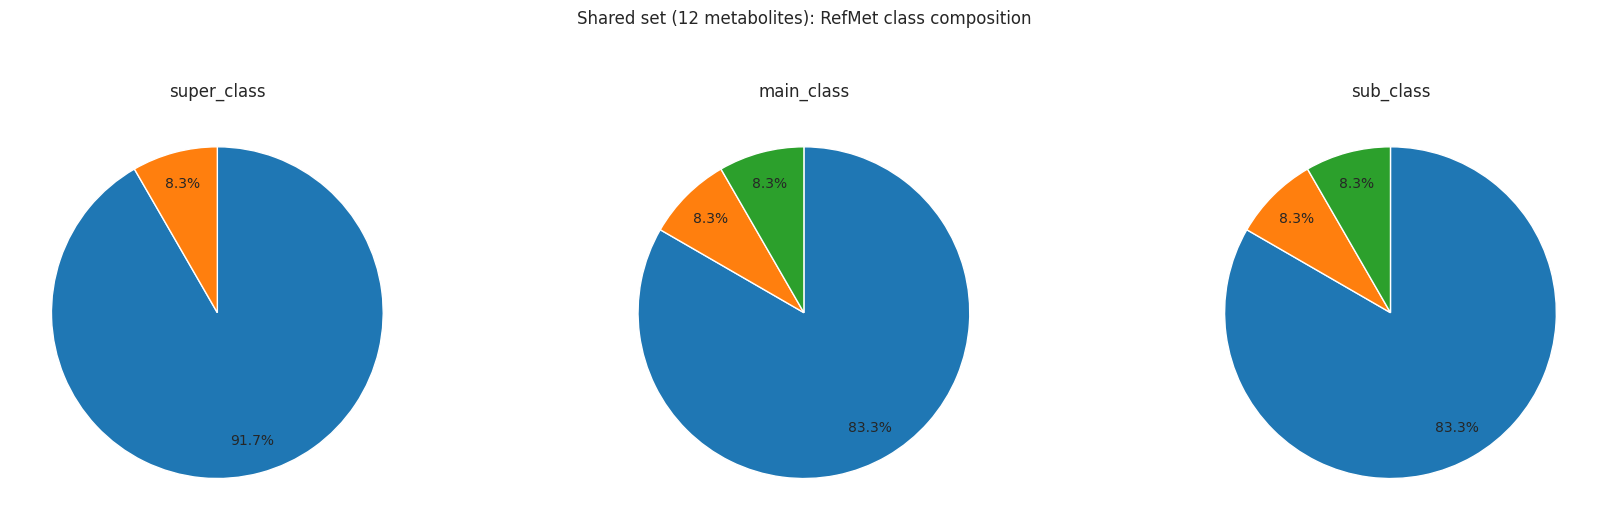


Legend for super_class:
  1. Organic acids (n=11)
  2. Organic nitrogen compounds (n=1)

Legend for main_class:
  1. Amino acids and peptides (n=10)
  2. Amines (n=1)
  3. Sulfonic acids (n=1)

Legend for sub_class:
  1. Amino acids (n=10)
  2. 1,2-aminoalcohols (n=1)
  3. Sulfonic acids (n=1)


In [13]:
# Part 2: Class distribution of shared metabolites

def parse_st(fname):
    m = re.match(r"(ST\d{6})_(AN\d{6})_datatable\.tsv$", fname)
    return m.group(1) if m else None

type_map = dict(zip(
    selected_heart_studies_df["study_id"].astype(str),
    selected_heart_studies_df["metabolomics_type_inferred"].astype(str).str.lower()
))

comp_mets = set()
targ_mets = set()

for p in glob.glob(os.path.join(DATA_DIR, "*_datatable.tsv")):
    st = parse_st(os.path.basename(p))
    if st is None:
        continue

    hdr = pd.read_csv(p, sep="\t", nrows=0)
    met_cols = [c for c in hdr.columns if c not in ["Samples", "Class"]]

    if st == COMPARATOR_STUDY_ID:
        comp_mets |= set(met_cols)
    elif type_map.get(st) == "targeted":
        targ_mets |= set(met_cols)

shared = sorted(comp_mets.intersection(targ_mets))
print("Comparator metabolites:", len(comp_mets))
print("MoTrPAC targeted metabolites (union):", len(targ_mets))
print("Shared comparator vs MoTrPAC targeted:", len(shared))
print("Shared names:", shared)

MW_BASE = "https://www.metabolomicsworkbench.org/rest"
CACHE_PATH = "./data/refmet_cache.csv"
_cache_cols = ["input_name","refmet_name","refmet_id","formula","exactmass","super_class","main_class","sub_class","error"]

_cache = {}
if os.path.exists(CACHE_PATH):
    cache_df = pd.read_csv(CACHE_PATH)
    for c in _cache_cols:
        if c not in cache_df.columns:
            cache_df[c] = None
    cache_df = cache_df[_cache_cols]
    _cache = {r["input_name"]: r for _, r in cache_df.iterrows()}
    print("Loaded cache:", len(_cache), "entries")

def save_cache():
    os.makedirs(os.path.dirname(CACHE_PATH) or ".", exist_ok=True)
    pd.DataFrame(list(_cache.values()))[_cache_cols].to_csv(CACHE_PATH, index=False)

def refmet_match_one(name: str, timeout: int = 30) -> dict:
    url = f"{MW_BASE}/refmet/match/{requests.utils.quote(str(name))}"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    j = r.json()
    return {
        "input_name": name,
        "refmet_name": j.get("refmet_name"),
        "refmet_id": j.get("refmet_id"),
        "formula": j.get("formula"),
        "exactmass": j.get("exactmass"),
        "super_class": j.get("super_class"),
        "main_class": j.get("main_class"),
        "sub_class": j.get("sub_class"),
        "error": None,
    }

def refmet_match_cached(name: str) -> dict:
    if name in _cache:
        return _cache[name]
    try:
        rec = refmet_match_one(name)
    except Exception as e:
        rec = {c: None for c in _cache_cols}
        rec["input_name"] = name
        rec["error"] = str(e)
    _cache[name] = rec
    return rec

ann = pd.DataFrame([refmet_match_cached(m) for m in shared])
save_cache()
display(ann)

def pie_on_ax(ax, counts: pd.Series, title: str):
    counts = counts.fillna("Unmatched/Unknown")
    labels = counts.index.astype(str).tolist()
    sizes = counts.values.astype(float)

    ax.pie(
        sizes,
        startangle=90,
        counterclock=False,
        labels=None,
        autopct=lambda p: f"{p:.1f}%" if p >= 5 else "",
        pctdistance=0.8
    )
    ax.set_title(title)

    legend_lines = [f"{i+1}. {labels[i]} (n={int(sizes[i])})" for i in range(len(labels))]
    return legend_lines

levels = ["super_class", "main_class", "sub_class"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Shared set ({len(shared)} metabolites): RefMet class composition", y=1.05)

legends = {}
for ax, lvl in zip(axes, levels):
    counts = ann[lvl].fillna("Unmatched/Unknown").value_counts()
    legends[lvl] = pie_on_ax(ax, counts, title=lvl)

plt.tight_layout()
plt.show()

for lvl in levels:
    print(f"\nLegend for {lvl}:")
    for line in legends[lvl]:
        print("  " + line)

Auto-selected overlapping metabolites:
['Alanine', 'Asparagine', 'Ethanolamine', 'Glutamine', 'Glycine', 'Histidine', 'Lysine', 'Proline', 'Serine', 'Taurine', 'Threonine', 'Tyrosine']


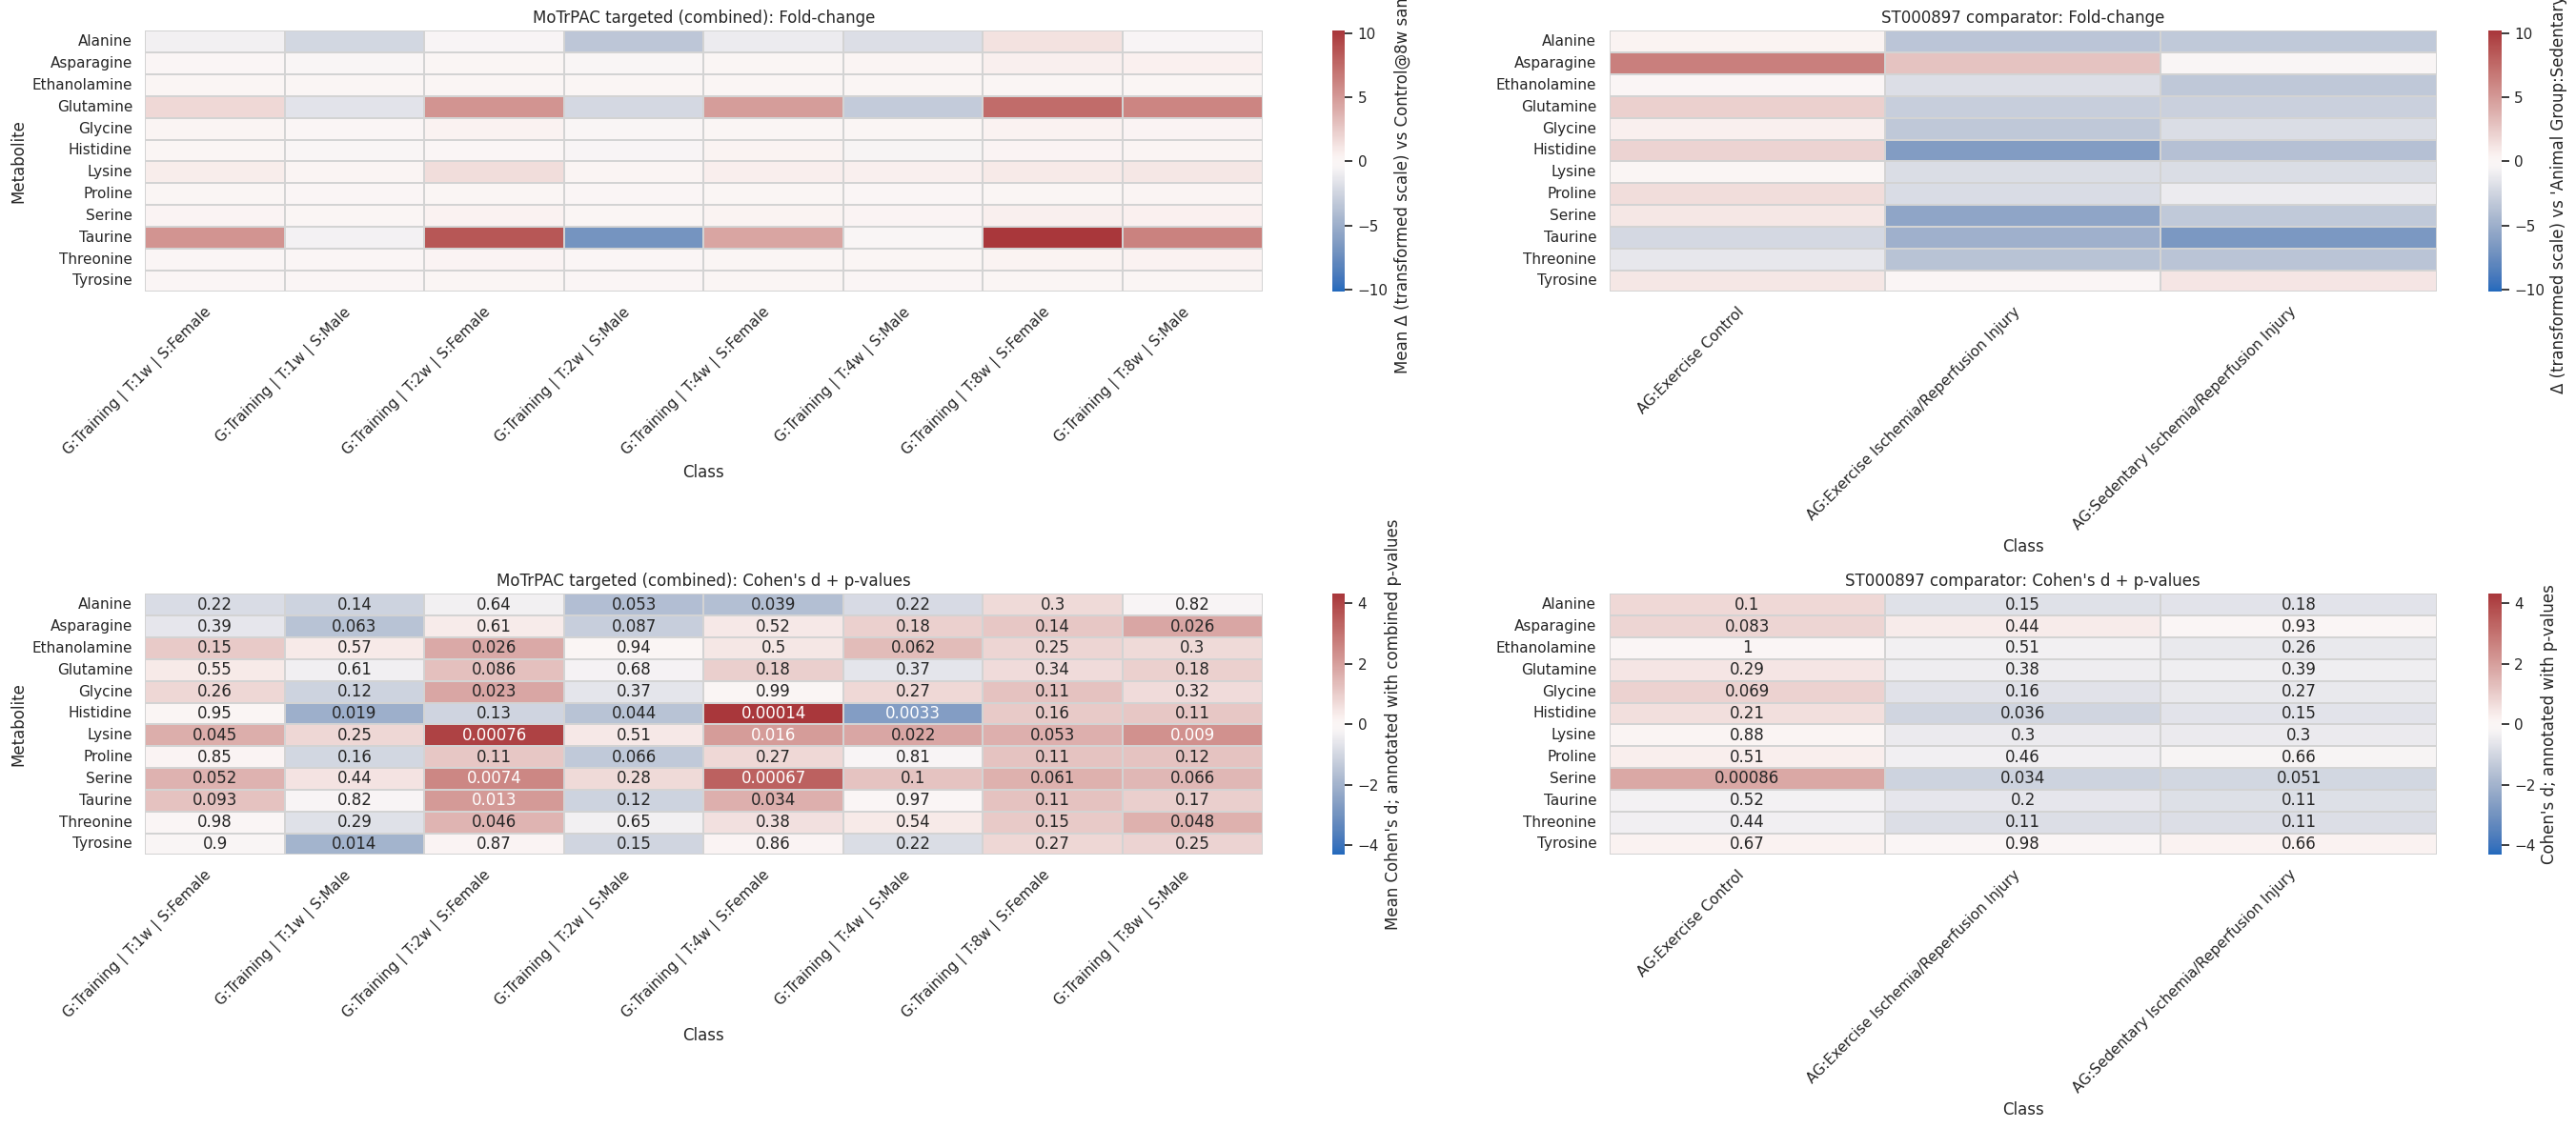

In [14]:
# Part 3: Data transformation and statistics: normalization, significance, effect size, and fold change

OVERLAP_FEATURES = []
COMPARATOR_BASELINE_CLASS = "Animal Group:Sedentary Control"
MOTRPAC_CONTROL_PREFIX = "Group:Control"
MOTRPAC_TIMEPOINT_SUBSTR = "Timepoint:8 weeks of training or control time"
EXCLUDE_QC = True
ANNOTATE_WITH = "p"  # "p" or "q"
PVAL_FORMAT = "{:.2g}"
ZERO_AS_MISSING = False
DROP_BASELINE_COLUMNS = True

def parse_study_analysis(fname):
    m = re.match(r"(ST\d{6})_(AN\d{6})_datatable\.tsv$", fname)
    return (m.group(1), m.group(2)) if m else (None, None)

type_map = dict(zip(
    selected_heart_studies_df["study_id"].astype(str),
    selected_heart_studies_df["metabolomics_type_inferred"].astype(str).str.lower()
))

transform_map = dict(zip(
    norm_check_df["study_id"].astype(str) + "||" + norm_check_df["analysis_id"].astype(str),
    norm_check_df["recommended_transform"].astype(str)
))

def apply_transform(series: pd.Series, recommendation: str) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    rec = (recommendation or "").lower()
    if "already log-like" in rec:
        return x
    if ("log2" in rec) or ("small" in rec) or ("mixed" in rec) or ("intensity" in rec) or ("inspect" in rec):
        return np.log2(x + 1e-6)
    if np.nanmax(x.values) > 100:
        return np.log2(x + 1e-6)
    return x

def get_feature_cols_from_file(p):
    hdr = pd.read_csv(p, sep="\t", nrows=0)
    return [c for c in hdr.columns if c not in ["Samples", "Class"]]

def build_motrpac_baseline_map(class_levels):
    levels = [str(x) for x in class_levels]
    if EXCLUDE_QC:
        levels = [c for c in levels if "Group:QC-" not in c]

    controls = [c for c in levels if (MOTRPAC_CONTROL_PREFIX in c) and (MOTRPAC_TIMEPOINT_SUBSTR in c)]
    control_by_sex = {}
    for c in controls:
        if "Sex:Female" in c:
            control_by_sex["Female"] = c
        if "Sex:Male" in c:
            control_by_sex["Male"] = c

    baseline_for = {}
    for lvl in levels:
        if "Sex:Female" in lvl and "Female" in control_by_sex:
            baseline_for[lvl] = control_by_sex["Female"]
        elif "Sex:Male" in lvl and "Male" in control_by_sex:
            baseline_for[lvl] = control_by_sex["Male"]
        else:
            baseline_for[lvl] = None
    return baseline_for

def cohen_d(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    sa = np.nanstd(a, ddof=1)
    sb = np.nanstd(b, ddof=1)
    sp = np.sqrt(((na - 1) * sa**2 + (nb - 1) * sb**2) / (na + nb - 2))
    if not np.isfinite(sp) or sp == 0:
        return np.nan
    return (np.nanmean(a) - np.nanmean(b)) / sp

def fisher_combine(pvals):
    pvals = np.array([p for p in pvals if np.isfinite(p) and (p > 0) and (p <= 1)], dtype=float)
    if pvals.size == 0:
        return np.nan
    return float(combine_pvalues(pvals, method="fisher")[1])

def add_qvals(df, pcol="pval_comb"):
    p = df[pcol].to_numpy()
    ok = np.isfinite(p)
    q = np.full_like(p, np.nan, dtype=float)
    if ok.sum() > 0:
        q[ok] = multipletests(p[ok], method="fdr_bh")[1]
    out = df.copy()
    out["qval"] = q
    return out

def shorten_labels(labels):
    out = []
    for s in labels:
        s = str(s)
        s = s.replace("Animal Group:", "AG:")
        s = s.replace("Group:", "G:")
        s = s.replace("Timepoint:", "T:")
        s = s.replace(" weeks of training or control time", "w")
        s = s.replace(" week of training or control time", "w")
        s = s.replace(" weeks of training", "w")
        s = s.replace("Sex:", "S:")
        out.append(s)
    return out

paths = sorted(glob.glob(os.path.join(DATA_DIR, "*_datatable.tsv")))
if not paths:
    raise FileNotFoundError(f"No datatables found in {DATA_DIR}")

comp_feats, targ_feats = set(), set()
for p in paths:
    st, an = parse_study_analysis(os.path.basename(p))
    if st is None:
        continue
    feats = set(get_feature_cols_from_file(p))
    if st == COMPARATOR_STUDY_ID:
        comp_feats |= feats
    elif type_map.get(st) == "targeted":
        targ_feats |= feats

shared = sorted(comp_feats & targ_feats)
if not OVERLAP_FEATURES:
    OVERLAP_FEATURES = shared[:12]
    print("Auto-selected overlapping metabolites:")
    print(OVERLAP_FEATURES)

motrpac_rows, comp_rows = [], []

for p in paths:
    st, an = parse_study_analysis(os.path.basename(p))
    if st is None:
        continue

    is_comp = (st == COMPARATOR_STUDY_ID)
    is_targ = (type_map.get(st) == "targeted")
    if (not is_comp) and (not is_targ):
        continue

    dat = pd.read_csv(p, sep="\t", low_memory=False)
    feats_here = [f for f in OVERLAP_FEATURES if f in dat.columns]
    if len(feats_here) == 0:
        continue

    if is_targ and EXCLUDE_QC:
        dat = dat[~dat["Class"].astype(str).str.contains("Group:QC-", na=False)].copy()

    rec = transform_map.get(f"{st}||{an}", "")

    df = dat[["Samples", "Class"] + feats_here].copy()
    for f in feats_here:
        df[f] = apply_transform(df[f], rec)
        if ZERO_AS_MISSING:
            df.loc[df[f] == 0, f] = np.nan

    classes = df["Class"].astype(str).unique().tolist()

    if is_comp:
        base = COMPARATOR_BASELINE_CLASS
        base_df = df[df["Class"].astype(str) == base]
        for grp in classes:
            grp_df = df[df["Class"].astype(str) == grp]
            for f in feats_here:
                a = grp_df[f].dropna().values
                b = base_df[f].dropna().values
                fc = float(np.nanmean(a) - np.nanmean(b)) if (len(a) and len(b)) else np.nan
                d  = float(cohen_d(a, b))
                pval = float(ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue) if (len(a) >= 2 and len(b) >= 2) else np.nan
                comp_rows.append((st, an, grp, f, fc, d, pval))

    if is_targ:
        baseline_map = build_motrpac_baseline_map(classes)
        for grp in classes:
            base = baseline_map.get(grp)
            if base is None:
                continue
            grp_df  = df[df["Class"].astype(str) == grp]
            base_df = df[df["Class"].astype(str) == base]
            for f in feats_here:
                a = grp_df[f].dropna().values
                b = base_df[f].dropna().values
                fc = float(np.nanmean(a) - np.nanmean(b)) if (len(a) and len(b)) else np.nan
                d  = float(cohen_d(a, b))
                pval = float(ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue) if (len(a) >= 2 and len(b) >= 2) else np.nan
                motrpac_rows.append((st, an, grp, f, fc, d, pval))

motrpac_df = pd.DataFrame(motrpac_rows, columns=["study_id","analysis_id","group","feature","fc","d","pval"])
comp_df    = pd.DataFrame(comp_rows,    columns=["study_id","analysis_id","group","feature","fc","d","pval"])

motrpac_meta = (
    motrpac_df.groupby(["group","feature"], as_index=False)
    .agg(fc=("fc","mean"), d=("d","mean"), pval_comb=("pval", fisher_combine))
)
motrpac_meta = add_qvals(motrpac_meta, "pval_comb")

comp_meta = (
    comp_df.groupby(["group","feature"], as_index=False)
    .agg(fc=("fc","mean"), d=("d","mean"), pval_comb=("pval", fisher_combine))
)
comp_meta = add_qvals(comp_meta, "pval_comb")

targ_fc = motrpac_meta.pivot(index="feature", columns="group", values="fc").reindex(OVERLAP_FEATURES)
targ_d  = motrpac_meta.pivot(index="feature", columns="group", values="d").reindex(OVERLAP_FEATURES)
targ_p  = motrpac_meta.pivot(index="feature", columns="group", values=("qval" if ANNOTATE_WITH=="q" else "pval_comb")).reindex(OVERLAP_FEATURES)

comp_fc = comp_meta.pivot(index="feature", columns="group", values="fc").reindex(OVERLAP_FEATURES)
comp_d  = comp_meta.pivot(index="feature", columns="group", values="d").reindex(OVERLAP_FEATURES)
comp_p  = comp_meta.pivot(index="feature", columns="group", values=("qval" if ANNOTATE_WITH=="q" else "pval_comb")).reindex(OVERLAP_FEATURES)

baseline_cols_motrpac = [c for c in targ_fc.columns if (MOTRPAC_CONTROL_PREFIX in str(c)) and (MOTRPAC_TIMEPOINT_SUBSTR in str(c))]
baseline_cols_comp = [COMPARATOR_BASELINE_CLASS] if COMPARATOR_BASELINE_CLASS in comp_fc.columns else []

if DROP_BASELINE_COLUMNS:
    targ_fc = targ_fc.drop(columns=baseline_cols_motrpac, errors="ignore")
    targ_d  = targ_d.drop(columns=baseline_cols_motrpac, errors="ignore")
    targ_p  = targ_p.drop(columns=baseline_cols_motrpac, errors="ignore")

    comp_fc = comp_fc.drop(columns=baseline_cols_comp, errors="ignore")
    comp_d  = comp_d.drop(columns=baseline_cols_comp, errors="ignore")
    comp_p  = comp_p.drop(columns=baseline_cols_comp, errors="ignore")

targ_annot = targ_p.apply(lambda col: col.map(lambda x: "" if not np.isfinite(x) else PVAL_FORMAT.format(x))).astype(str)
comp_annot = comp_p.apply(lambda col: col.map(lambda x: "" if not np.isfinite(x) else PVAL_FORMAT.format(x))).astype(str)

def sym_vmax(*mats):
    vals = np.concatenate([m.to_numpy().ravel() for m in mats])
    vals = vals[np.isfinite(vals)]
    v = float(np.max(np.abs(vals))) if vals.size else 1.0
    return max(v, 0.5)

v_fc = sym_vmax(targ_fc, comp_fc)
v_d  = sym_vmax(targ_d,  comp_d)

sns.set(context="notebook", style="white")
fig, axes = plt.subplots(2, 2, figsize=(28, 12), gridspec_kw={"width_ratios":[1.35, 1]})

sns.heatmap(targ_fc, ax=axes[0,0], cmap="vlag", center=0, vmin=-v_fc, vmax=v_fc,
            linewidths=0.3, linecolor="lightgrey",
            cbar_kws={"label":"Mean Δ (transformed scale) vs Control@8w same sex"})
axes[0,0].set_title("MoTrPAC targeted (combined): Fold-change")
axes[0,0].set_xlabel("Class")
axes[0,0].set_ylabel("Metabolite")
axes[0,0].set_xticklabels(shorten_labels(targ_fc.columns), rotation=45, ha="right")

sns.heatmap(comp_fc, ax=axes[0,1], cmap="vlag", center=0, vmin=-v_fc, vmax=v_fc,
            linewidths=0.3, linecolor="lightgrey",
            cbar_kws={"label":f"Δ (transformed scale) vs '{COMPARATOR_BASELINE_CLASS}'"})
axes[0,1].set_title(f"{COMPARATOR_STUDY_ID} comparator: Fold-change")
axes[0,1].set_xlabel("Class")
axes[0,1].set_ylabel("")
axes[0,1].set_xticklabels(shorten_labels(comp_fc.columns), rotation=45, ha="right")

sns.heatmap(targ_d, ax=axes[1,0], cmap="vlag", center=0, vmin=-v_d, vmax=v_d,
            annot=targ_annot, fmt="",
            linewidths=0.3, linecolor="lightgrey",
            cbar_kws={"label":f"Mean Cohen's d; annotated with combined {ANNOTATE_WITH}-values"})
axes[1,0].set_title(f"MoTrPAC targeted (combined): Cohen's d + {ANNOTATE_WITH}-values")
axes[1,0].set_xlabel("Class")
axes[1,0].set_ylabel("Metabolite")
axes[1,0].set_xticklabels(shorten_labels(targ_d.columns), rotation=45, ha="right")

sns.heatmap(comp_d, ax=axes[1,1], cmap="vlag", center=0, vmin=-v_d, vmax=v_d,
            annot=comp_annot, fmt="",
            linewidths=0.3, linecolor="lightgrey",
            cbar_kws={"label":f"Cohen's d; annotated with {ANNOTATE_WITH}-values"})
axes[1,1].set_title(f"{COMPARATOR_STUDY_ID} comparator: Cohen's d + {ANNOTATE_WITH}-values")
axes[1,1].set_xlabel("Class")
axes[1,1].set_ylabel("")
axes[1,1].set_xticklabels(shorten_labels(comp_d.columns), rotation=45, ha="right")

plt.tight_layout()
plt.show()

targ_fc.to_csv("heatmap_motrpac_targeted_fc.tsv", sep="\t", na_rep="NA")
comp_fc.to_csv("heatmap_comparator_fc.tsv", sep="\t", na_rep="NA")
targ_d.to_csv("heatmap_motrpac_targeted_cohens_d.tsv", sep="\t", na_rep="NA")
comp_d.to_csv("heatmap_comparator_cohens_d.tsv", sep="\t", na_rep="NA")
targ_p.to_csv(f"heatmap_motrpac_targeted_{ANNOTATE_WITH}vals.tsv", sep="\t", na_rep="NA")
comp_p.to_csv(f"heatmap_comparator_{ANNOTATE_WITH}vals.tsv", sep="\t", na_rep="NA")


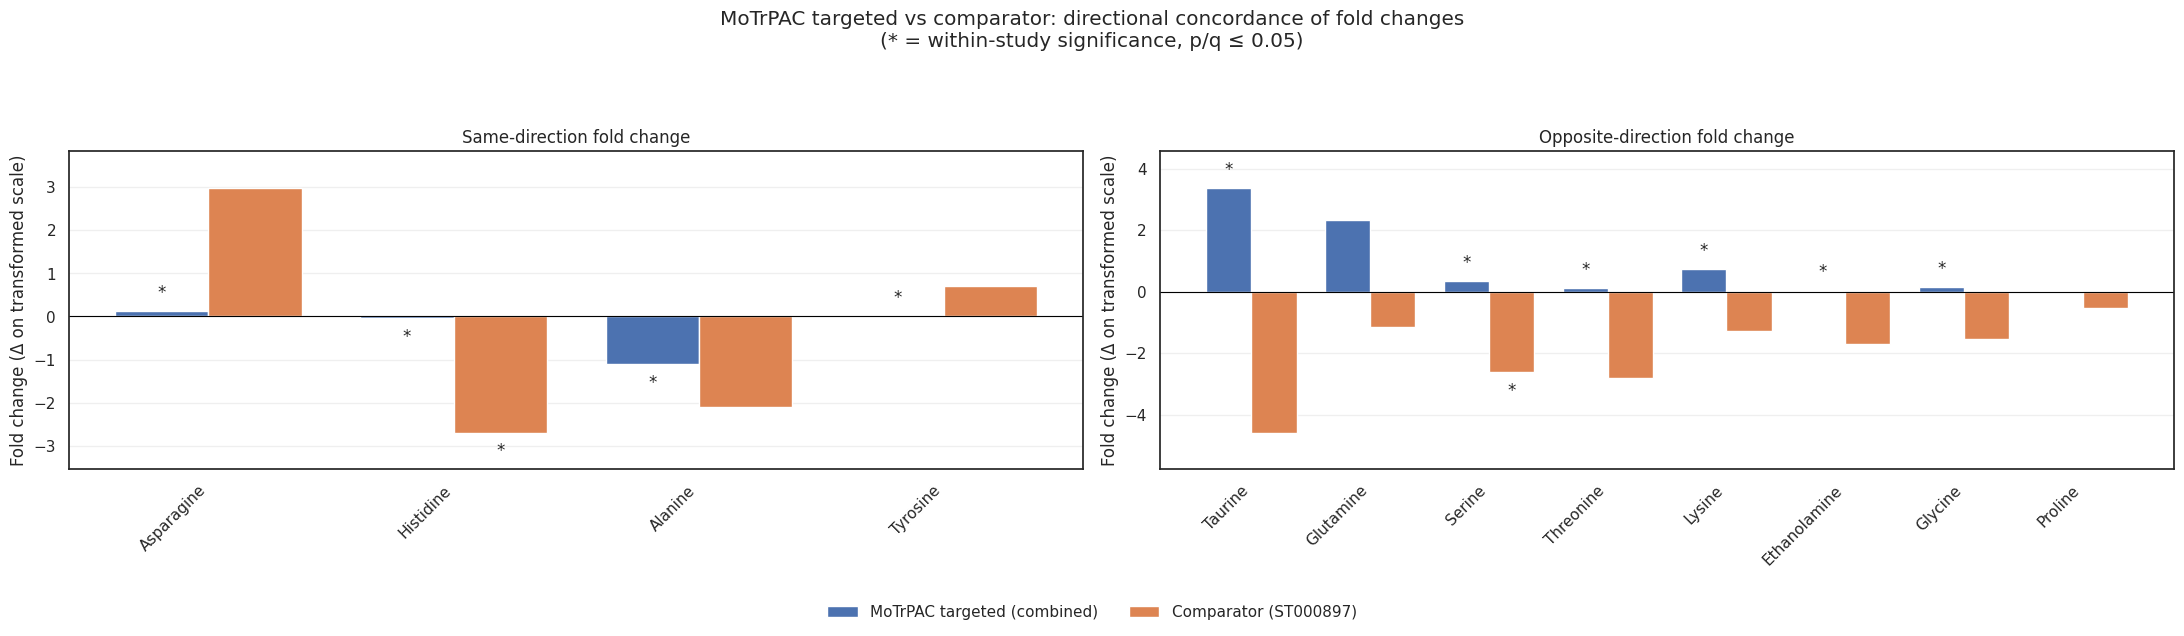

In [15]:
# Part 4: directional concordance

ALPHA = 0.05
AGG = "mean_abs"
SORT_BY = "abs_diff"
DROP_ZERO_DIR = True

for name in ["targ_fc", "comp_fc", "targ_p", "comp_p"]:
    assert name in globals(), f"Required object '{name}' not found in globals()"

mets = sorted(set(targ_fc.index.astype(str)) & set(comp_fc.index.astype(str)))
targ_fc2 = targ_fc.loc[mets].copy()
comp_fc2 = comp_fc.loc[mets].copy()
targ_p2  = targ_p.loc[mets].copy()
comp_p2  = comp_p.loc[mets].copy()

def collapse_fc_and_sig(fc_mat: pd.DataFrame, p_mat: pd.DataFrame, agg: str):
    fc = fc_mat.apply(pd.to_numeric, errors="coerce")
    pv = p_mat.apply(pd.to_numeric, errors="coerce")

    sig = (pv <= ALPHA).any(axis=1)

    if agg in ("mean", "mean_abs"):
        fc1 = fc.mean(axis=1, skipna=True)

    elif agg == "max_abs":
        idx = fc.abs().idxmax(axis=1)
        fc1 = pd.Series([fc.loc[m, idx[m]] if pd.notna(idx[m]) else np.nan for m in fc.index], index=fc.index)

    else:
        raise ValueError("Unknown agg: " + agg)

    return fc1, sig

targ_fc1, targ_sig = collapse_fc_and_sig(targ_fc2, targ_p2, AGG)
comp_fc1, comp_sig = collapse_fc_and_sig(comp_fc2, comp_p2, AGG)

df = pd.DataFrame({
    "metabolite": mets,
    "fc_motrpac": targ_fc1.values,
    "fc_comp": comp_fc1.values,
    "sig_motrpac": targ_sig.values,
    "sig_comp": comp_sig.values,
}).set_index("metabolite").dropna(subset=["fc_motrpac", "fc_comp"])

def sgn(x):
    if x > 0: return 1
    if x < 0: return -1
    return 0

df["dir_motrpac"] = df["fc_motrpac"].apply(sgn)
df["dir_comp"]    = df["fc_comp"].apply(sgn)

if DROP_ZERO_DIR:
    df = df[(df["dir_motrpac"] != 0) & (df["dir_comp"] != 0)]

same_df = df[df["dir_motrpac"] == df["dir_comp"]].copy()
opp_df  = df[df["dir_motrpac"] != df["dir_comp"]].copy()

if SORT_BY == "abs_diff":
    same_df["sort_key"] = (same_df["fc_motrpac"] - same_df["fc_comp"]).abs()
    opp_df["sort_key"]  = (opp_df["fc_motrpac"] - opp_df["fc_comp"]).abs()
elif SORT_BY == "abs_mean":
    same_df["sort_key"] = same_df[["fc_motrpac","fc_comp"]].abs().mean(axis=1)
    opp_df["sort_key"]  = opp_df[["fc_motrpac","fc_comp"]].abs().mean(axis=1)
else:
    raise ValueError("Unknown SORT_BY: " + SORT_BY)

same_df = same_df.sort_values("sort_key", ascending=False)
opp_df  = opp_df.sort_values("sort_key", ascending=False)

def plot_two_barsets(ax, subdf, title):
    mets = subdf.index.tolist()
    x = np.arange(len(mets))
    w = 0.38

    y1 = subdf["fc_motrpac"].values
    y2 = subdf["fc_comp"].values

    b1 = ax.bar(x - w/2, y1, width=w, label="MoTrPAC targeted (combined)")
    b2 = ax.bar(x + w/2, y2, width=w, label="Comparator (ST000897)")

    ymin = np.nanmin(np.concatenate([y1, y2])) if len(mets) else -1
    ymax = np.nanmax(np.concatenate([y1, y2])) if len(mets) else 1
    pad = 0.15 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

    def add_stars(bars, sig_flags):
        offset = 0.03 * (ax.get_ylim()[1] - ax.get_ylim()[0])
        for rect, sig in zip(bars, sig_flags):
            if not sig:
                continue
            h = rect.get_height()
            x0 = rect.get_x() + rect.get_width()/2
            y0 = h + offset if h >= 0 else h - offset
            ax.text(x0, y0, "*", ha="center", va="bottom" if h >= 0 else "top", fontsize=12)

    add_stars(b1, subdf["sig_motrpac"].values)
    add_stars(b2, subdf["sig_comp"].values)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(mets, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Fold change (Δ on transformed scale)")
    ax.grid(axis="y", alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))

if same_df.empty:
    axes[0].text(0.5, 0.5, "No same-direction metabolites\n(after filtering)", ha="center", va="center")
    axes[0].set_axis_off()
else:
    plot_two_barsets(axes[0], same_df, "Same-direction fold change")

if opp_df.empty:
    axes[1].text(0.5, 0.5, "No opposite-direction metabolites\n(after filtering)", ha="center", va="center")
    axes[1].set_axis_off()
else:
    plot_two_barsets(axes[1], opp_df, "Opposite-direction fold change")

fig.suptitle(
    f"MoTrPAC targeted vs comparator: directional concordance of fold changes\n"
    f"(* = within-study significance, p/q ≤ {ALPHA})",
    y=1.02
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()


In [16]:
# Part 5: compare data interactively!

ALPHA = 0.05
SUMMARY_AGG = "mean"
TOP_K_CLASSES = None

for name in ["targ_fc", "targ_p", "comp_fc", "comp_p"]:
    assert name in globals(), f"Missing required object: {name}"

def sgn(x):
    if x > 0: return 1
    if x < 0: return -1
    return 0

def summarize_fc(fc_mat, agg="mean"):
    fc = fc_mat.apply(pd.to_numeric, errors="coerce")
    if agg == "mean":
        return fc.mean(axis=1, skipna=True)
    if agg == "max_abs":
        idx = fc.abs().idxmax(axis=1)
        return pd.Series([fc.loc[m, idx[m]] if pd.notna(idx[m]) else np.nan for m in fc.index], index=fc.index)
    raise ValueError("Unknown agg")

common_mets = sorted(set(targ_fc.index.astype(str)) & set(comp_fc.index.astype(str)))
t_fc1 = summarize_fc(targ_fc.loc[common_mets], SUMMARY_AGG)
c_fc1 = summarize_fc(comp_fc.loc[common_mets], SUMMARY_AGG)

sum_dir = pd.DataFrame({"fc_motrpac": t_fc1, "fc_comp": c_fc1}).dropna()
sum_dir["dir_motrpac"] = sum_dir["fc_motrpac"].apply(sgn)
sum_dir["dir_comp"] = sum_dir["fc_comp"].apply(sgn)
sum_dir = sum_dir[(sum_dir["dir_motrpac"] != 0) & (sum_dir["dir_comp"] != 0)]

same_mets = sum_dir[sum_dir["dir_motrpac"] == sum_dir["dir_comp"]].index.tolist()
opp_mets  = sum_dir[sum_dir["dir_motrpac"] != sum_dir["dir_comp"]].index.tolist()

def make_long_within(fc_mat, p_mat, metabolites, panel_name):
    fc = fc_mat.loc[metabolites].apply(pd.to_numeric, errors="coerce")
    pv = p_mat.loc[metabolites].apply(pd.to_numeric, errors="coerce")

    fc_long = fc.stack(future_stack=True).reset_index()
    pv_long = pv.stack(future_stack=True).reset_index()
    fc_long.columns = ["metabolite", "class", "fc"]
    pv_long.columns = ["metabolite", "class", "p"]

    long = fc_long.merge(pv_long, on=["metabolite", "class"], how="left")
    long["fc"] = pd.to_numeric(long["fc"], errors="coerce")
    long["p"]  = pd.to_numeric(long["p"], errors="coerce")
    long = long[np.isfinite(long["fc"])].copy()

    long["sig"] = np.isfinite(long["p"]) & (long["p"] <= ALPHA)
    long["panel"] = panel_name

    if TOP_K_CLASSES is not None:
        long["absfc"] = long["fc"].abs()
        long = (long.sort_values(["metabolite","absfc"], ascending=[True, False])
                    .groupby("metabolite", as_index=False)
                    .head(TOP_K_CLASSES)
                    .drop(columns=["absfc"]))
    return long

same_long = pd.concat([
    make_long_within(targ_fc, targ_p, same_mets, "MoTrPAC"),
    make_long_within(comp_fc, comp_p, same_mets, "Comparator"),
], ignore_index=True)

opp_long = pd.concat([
    make_long_within(targ_fc, targ_p, opp_mets, "MoTrPAC"),
    make_long_within(comp_fc, comp_p, opp_mets, "Comparator"),
], ignore_index=True)

def interactive_within_plot(long_df, title):
    d = long_df.copy()

    d["sig_star"] = np.where(d["sig"], "*", "")
    d["p_fmt"] = d["p"].map(lambda x: "" if not np.isfinite(x) else f"{x:.2g}")
    d["hover"] = (
        "Metabolite: " + d["metabolite"].astype(str) +
        "<br>Panel: " + d["panel"].astype(str) +
        "<br>Class: " + d["class"].astype(str) +
        "<br>FC: " + d["fc"].map(lambda x: f"{x:.3g}") +
        "<br>p/q: " + d["p_fmt"] + d["sig_star"]
    )

    fig = px.bar(
        d,
        x="metabolite",
        y="fc",
        color="panel",
        barmode="group",
        facet_col=None,
        hover_name="class",
        hover_data={"class": False, "panel": False, "fc": False, "metabolite": False, "hover": True},
        title=title
    )
    fig.update_traces(hovertemplate="%{customdata[0]}<extra></extra>")
    fig.update_layout(
        xaxis_title="Metabolite",
        yaxis_title="Within-group fold change (Δ on transformed scale)",
        legend_title="Source",
        bargap=0.25
    )
    fig.add_hline(y=0, line_width=1, line_color="black")
    return fig

fig_same = interactive_within_plot(same_long, "Same-direction: within-study groups (hover to view study group!)")
fig_opp  = interactive_within_plot(opp_long,  "Opposite-direction: within-study groups (hover to view study group!)")

fig_same.show()
fig_opp.show()

---

## Learning Assessments (Learning Objective 3)

**Q1. Why might “matching column names” may not be enough to determine if a metabolite is found across studies?**    
A. Column names are always standardized by RefMet before being stored.  
B. Labs/platforms may differ in naming metabolites/metabolite isoforms.     
C. Column names only represent sample IDs, not metabolites.  
D. If names match, the metabolite must be chemically identical and measured the same way.  

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: B**

- **A (Incorrect):** MW does not guarantee RefMet-standardized naming in uploaded datatables.
- **B (Correct):** Names can be ambiguous; multi-study analysis often needs standardized identifiers (e.g., RefMet ID) and method context.   
- **C (Incorrect):** In these datatables, `Samples` is sample ID; other columns are metabolite/feature columns.  
- **D (Incorrect):** Name matching does not guarantee chemical identity or comparable quantitation.  

</details>

**Q2. In the directional concordance step, how was "opposite-direction" determined?**  
A. Fold change              
B. Missingness  
C. Significance (p-values)  
D. Effect size

<details>
<summary><strong>Answer key + explanations</strong></summary>

**Correct answer: A**

- **A (Correct):** “Opposite-direction” was defined by opposing fold changes between studies.
- **B (Incorrect)**  
- **C (Incorrect)**  
- **D (Incorrect)**

</details>

## Recommended Next Steps

1.   Try the above workflow with other studies from the Metabolomics Workbench! To ensure successful comparisons, always check the data, metadata, labelling, and terminology for all studies uploaded to the Metabolomics Workbench.
2.   Explore the MoTrPAC data with the official R packages! Publicly released data are available through several R packages, which also include several functions to analyze the data. Visit the MoTrPAC Data Hub for more details! https://motrpac-data.org/code-repositories


